# Notebook 15: Day 12 — OCP slope scan ablation

**Purpose**: ROADMAP v0.3 Item 2 — test whether the OCP landscape (specifically dV/dx slope of negative electrode OCP) is a controlling variable for state-layer DC-AC acceleration emergence in Chen2020/M50 sim cell-internally. Independent of MJ1 comparison; sim/exp sign-coincidence reported descriptively but not used as pass/fail.

**Configuration**: X5-A baseline (Chen2020 + V_init=2.82V via set_initial_state(0.01688) + IDAKLU + 5-phase experiment) with one modification per ablation:
- Flatten NE OCP (multiply dV/dx by 0.5 in SOC range 0.3–0.7)
- Steepen NE OCP (multiply dV/dx by 1.5 in same SOC range)
- Plateau-shift NE OCP (shift OCV by +0.05 V in same SOC range)

**Metric**: dual metric reporting (Q80 scalar + A_Δt curve average over Q20–Q80), per Day 11 closure decision.

**Acceptance criteria** (per ROADMAP v0.3 Item 2):
- (a) OCP modification does not change sim cell-internal Δt direction → OCP slope is not primary controlling variable → ablations escalate to D (transport / diffusion) and B (parameter set replication)
- (b) OCP modification flips Δt direction on most cases → OCP slope IS primary controlling variable → next: OCP geometry comparison Chen2020 vs MJ1 (where MJ1 OCP data exists)
- (c) Selective flips in specific (DC, AC, f, SOC) regions → identify activation boundary, map under controlled OCP variations

**Caveat on interpretation**: OCP modifications in PyBaMM do not necessarily correspond to physical OCP shapes of any real cell; they are sim sensitivity probes. Conclusions: "OCP slope is/is not a controlling variable in Chen2020/M50 sim", NOT "OCP geometry causally explains the MJ1 phenomenon".

**Today's plan**: NE OCP first; PE OCP deferred to Day 13 if today's NE result is informative.

PyBaMM version: 26.3.1

Chen2020 NE OCP
Type:    function
Module:  builtins
Repr (first 500 chars):
  <function graphite_LGM50_ocp_Chen2020 at 0x116147560>
Callable: True

Chen2020 PE OCP
Type:    function
Module:  builtins
Callable: True

Evaluating NE OCP across stoichiometry [0, 1]
  Direct float call OK: ne_ocp(0.5) = 0.1331 V

Sample values:
  sto=0.001  →  NE OCP = 2.3071 V
  sto=0.205  →  NE OCP = 0.2153 V
  sto=0.510  →  NE OCP = 0.1330 V
  sto=0.816  →  NE OCP = 0.0920 V
  sto=0.999  →  NE OCP = 0.0920 V

NE OCP range: [0.0920, 2.3071] V
dV/dx range (numerical): [-1.0497, -0.0000] V/step


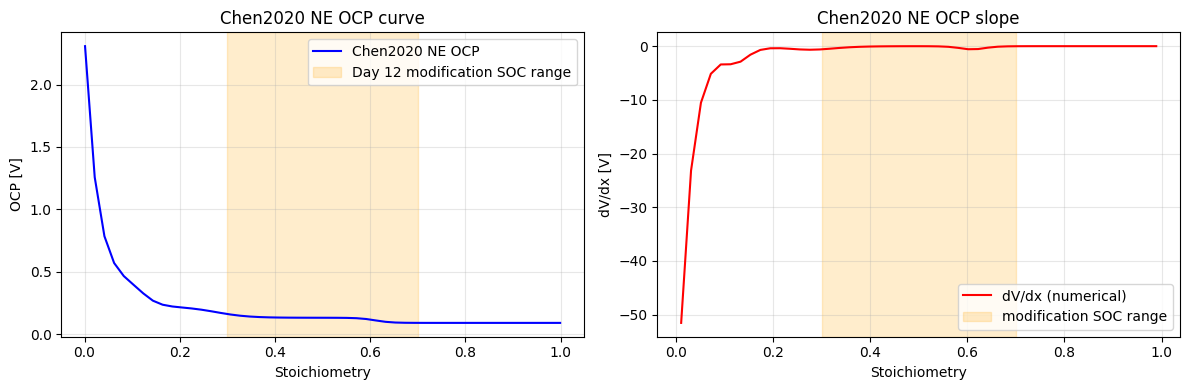


  ✓ Plotted to figures/day12_chen2020_ne_ocp_curve.png


In [1]:
# Day 12 Cell 1 — Chen2020 NE OCP representation probe
import pybamm
import numpy as np
import matplotlib.pyplot as plt

print(f"PyBaMM version: {pybamm.__version__}")

# === Step 1: Inspect Chen2020 NE OCP type ===
pv = pybamm.ParameterValues("Chen2020")

NE_OCP_KEY = "Negative electrode OCP [V]"
PE_OCP_KEY = "Positive electrode OCP [V]"

ne_ocp = pv[NE_OCP_KEY]
pe_ocp = pv[PE_OCP_KEY]

print()
print("=" * 70)
print("Chen2020 NE OCP")
print("=" * 70)
print(f"Type:    {type(ne_ocp).__name__}")
print(f"Module:  {type(ne_ocp).__module__}")
print(f"Repr (first 500 chars):")
print(f"  {repr(ne_ocp)[:500]}")
print(f"Callable: {callable(ne_ocp)}")

print()
print("=" * 70)
print("Chen2020 PE OCP")
print("=" * 70)
print(f"Type:    {type(pe_ocp).__name__}")
print(f"Module:  {type(pe_ocp).__module__}")
print(f"Callable: {callable(pe_ocp)}")

# === Step 2: Try to evaluate NE OCP at SOC grid ===
print()
print("=" * 70)
print("Evaluating NE OCP across stoichiometry [0, 1]")
print("=" * 70)

sto_grid = np.linspace(0.001, 0.999, 50)

# Chen2020 NE OCP is typically a callable function of stoichiometry
try:
    if callable(ne_ocp):
        # Try direct call with float
        try:
            v_test = float(ne_ocp(0.5))
            print(f"  Direct float call OK: ne_ocp(0.5) = {v_test:.4f} V")
            ne_ocp_values = np.array([float(ne_ocp(s)) for s in sto_grid])
        except Exception as e_direct:
            print(f"  Direct float call failed: {type(e_direct).__name__}: {str(e_direct)[:100]}")
            print(f"  Trying numpy array call...")
            try:
                ne_ocp_values = np.array(ne_ocp(sto_grid))
                print(f"  Array call OK: shape {ne_ocp_values.shape}")
            except Exception as e_arr:
                print(f"  Array call failed: {type(e_arr).__name__}: {str(e_arr)[:200]}")
                print(f"  Trying pybamm symbolic evaluation...")
                # Need symbolic eval
                sto_sym = pybamm.Variable("sto")
                expr = ne_ocp(sto_sym)
                print(f"  Symbolic expr type: {type(expr)}")
                print(f"  → Will need pybamm.Function based modification approach")
                ne_ocp_values = None
    else:
        print(f"  NE OCP not callable; cannot evaluate at numerical grid directly")
        ne_ocp_values = None
except Exception as e:
    print(f"  Outer exception: {type(e).__name__}: {str(e)[:200]}")
    ne_ocp_values = None

# === Step 3: Plot NE OCP if values obtained ===
if ne_ocp_values is not None:
    print()
    print("Sample values:")
    for i in [0, 10, 25, 40, 49]:
        print(f"  sto={sto_grid[i]:.3f}  →  NE OCP = {ne_ocp_values[i]:.4f} V")
    
    print()
    print(f"NE OCP range: [{ne_ocp_values.min():.4f}, {ne_ocp_values.max():.4f}] V")
    print(f"dV/dx range (numerical): [{np.diff(ne_ocp_values).min():+.4f}, {np.diff(ne_ocp_values).max():+.4f}] V/step")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(sto_grid, ne_ocp_values, 'b-', label='Chen2020 NE OCP')
    axes[0].axvspan(0.3, 0.7, alpha=0.2, color='orange', label='Day 12 modification SOC range')
    axes[0].set_xlabel('Stoichiometry')
    axes[0].set_ylabel('OCP [V]')
    axes[0].set_title('Chen2020 NE OCP curve')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Numerical dV/dx
    sto_mid = (sto_grid[:-1] + sto_grid[1:]) / 2
    dV_dx_numerical = np.diff(ne_ocp_values) / np.diff(sto_grid)
    axes[1].plot(sto_mid, dV_dx_numerical, 'r-', label='dV/dx (numerical)')
    axes[1].axvspan(0.3, 0.7, alpha=0.2, color='orange', label='modification SOC range')
    axes[1].set_xlabel('Stoichiometry')
    axes[1].set_ylabel('dV/dx [V]')
    axes[1].set_title('Chen2020 NE OCP slope')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../figures/day12_chen2020_ne_ocp_curve.png', dpi=100)
    plt.show()
    print(f"\n  ✓ Plotted to figures/day12_chen2020_ne_ocp_curve.png")
else:
    print()
    print(f"  ⚠ NE OCP could not be evaluated as numerical array")
    print(f"  → Modification strategy will need symbolic-level wrapping")

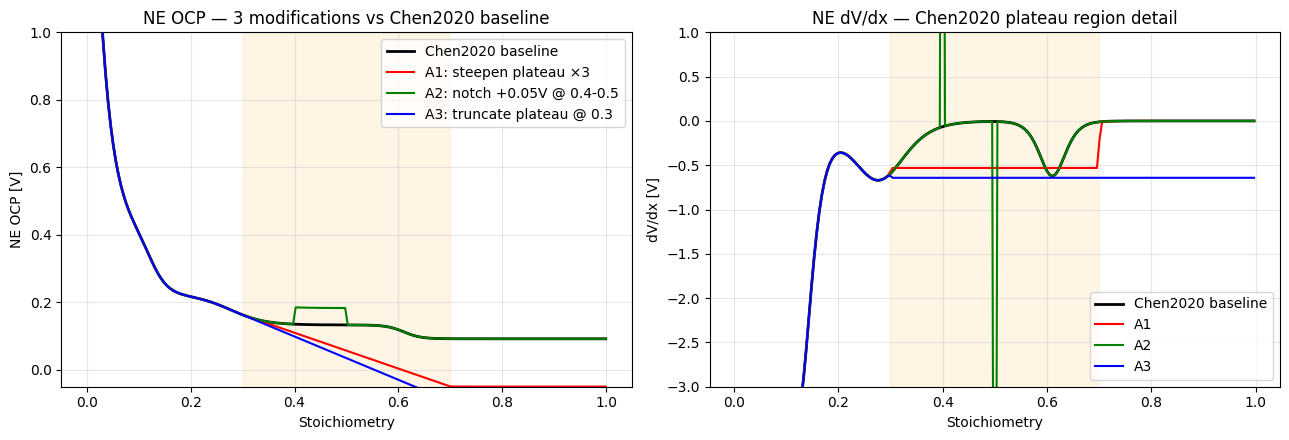

✓ Plot saved

V_init sanity check at SOC=0.01688 under each NE OCP modification
  Reference X5-A target V_init: 2.82V

  Chen2020 baseline        : V_init = 2.8206 V (target 2.82V, deviation +0.0006V; drift -0.00000V/s)


TypeError: float() argument must be a string or a real number, not 'Maximum'

In [2]:
# Day 12 Cell 2 — Define NE OCP modifications + V_init sanity check on modified cell

import pybamm
import numpy as np
import matplotlib.pyplot as plt

# Reference Chen2020 NE OCP function
pv_ref = pybamm.ParameterValues("Chen2020")
ne_ocp_chen = pv_ref["Negative electrode OCP [V]"]

# === Modifications ===

def make_steepen_plateau_ocp(multiplier=3.0, sto_lo=0.3, sto_hi=0.7):
    """Steepen the NE OCP plateau by `multiplier`× in [sto_lo, sto_hi].
    
    Returns a callable that mimics the Chen2020 NE OCP function shape outside
    the modified region; inside [sto_lo, sto_hi], adds a multiplicative
    perturbation to dV/dx anchored at the original boundary values.
    """
    # Sample original at boundaries
    v_lo_ref = float(ne_ocp_chen(sto_lo))
    v_hi_ref = float(ne_ocp_chen(sto_hi))
    # Original Δv across the window
    dv_orig = v_hi_ref - v_lo_ref
    # New Δv (steepened)
    dv_new = dv_orig * multiplier
    # New v_hi (anchor v_lo, scale slope)
    v_hi_new = v_lo_ref + dv_new
    # The function: outside window same as original; inside, linearly
    # interpolate from v_lo_ref to v_hi_new and offset everything past sto_hi
    # by (v_hi_new - v_hi_ref).
    offset_post = v_hi_new - v_hi_ref
    
    def modified_ocp(sto):
        sto_arr = np.atleast_1d(np.asarray(sto, dtype=float))
        v_orig = np.array([float(ne_ocp_chen(s)) for s in sto_arr])
        v_new = v_orig.copy()
        # Inside window: linear from v_lo_ref at sto_lo to v_hi_new at sto_hi
        in_window = (sto_arr >= sto_lo) & (sto_arr <= sto_hi)
        v_new[in_window] = (v_lo_ref + 
                            (sto_arr[in_window] - sto_lo) / (sto_hi - sto_lo) * dv_new)
        # Outside window past sto_hi: shifted by offset
        post_window = sto_arr > sto_hi
        v_new[post_window] = v_orig[post_window] + offset_post
        return v_new[0] if v_new.size == 1 else v_new
    
    return modified_ocp

def make_notch_ocp(shift_V=0.05, sto_lo=0.4, sto_hi=0.5):
    """Add a positive notch (+shift_V) in [sto_lo, sto_hi]."""
    def modified_ocp(sto):
        sto_arr = np.atleast_1d(np.asarray(sto, dtype=float))
        v = np.array([float(ne_ocp_chen(s)) for s in sto_arr])
        in_notch = (sto_arr >= sto_lo) & (sto_arr <= sto_hi)
        v[in_notch] += shift_V
        return v[0] if v.size == 1 else v
    return modified_ocp

def make_truncate_plateau_ocp(sto_truncate=0.3):
    """Truncate plateau early: replace OCP from sto_truncate onward with the
    pre-plateau slope continuation."""
    # Use slope from sto_truncate-0.05 to sto_truncate as continuation slope
    s1, s2 = sto_truncate - 0.05, sto_truncate
    v1, v2 = float(ne_ocp_chen(s1)), float(ne_ocp_chen(s2))
    slope_continue = (v2 - v1) / (s2 - s1)
    
    def modified_ocp(sto):
        sto_arr = np.atleast_1d(np.asarray(sto, dtype=float))
        v = np.array([float(ne_ocp_chen(s)) for s in sto_arr])
        post_trunc = sto_arr > sto_truncate
        v[post_trunc] = v2 + slope_continue * (sto_arr[post_trunc] - s2)
        return v[0] if v.size == 1 else v
    return modified_ocp

# Build the 3 modified functions
ocp_A1 = make_steepen_plateau_ocp(multiplier=3.0, sto_lo=0.3, sto_hi=0.7)
ocp_A2 = make_notch_ocp(shift_V=0.05, sto_lo=0.4, sto_hi=0.5)
ocp_A3 = make_truncate_plateau_ocp(sto_truncate=0.3)

# === Plot all 4 OCP curves for visual sanity ===
sto_grid = np.linspace(0.001, 0.999, 200)
v_chen = np.array([float(ne_ocp_chen(s)) for s in sto_grid])
v_A1 = ocp_A1(sto_grid)
v_A2 = ocp_A2(sto_grid)
v_A3 = ocp_A3(sto_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(sto_grid, v_chen, 'k-', lw=2, label='Chen2020 baseline')
ax.plot(sto_grid, v_A1, 'r-', lw=1.5, label='A1: steepen plateau ×3')
ax.plot(sto_grid, v_A2, 'g-', lw=1.5, label='A2: notch +0.05V @ 0.4-0.5')
ax.plot(sto_grid, v_A3, 'b-', lw=1.5, label='A3: truncate plateau @ 0.3')
ax.axvspan(0.3, 0.7, alpha=0.1, color='orange')
ax.set_xlabel('Stoichiometry')
ax.set_ylabel('NE OCP [V]')
ax.set_title('NE OCP — 3 modifications vs Chen2020 baseline')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.0)

# Numerical dV/dx
ax = axes[1]
sto_mid = (sto_grid[:-1] + sto_grid[1:]) / 2
ax.plot(sto_mid, np.diff(v_chen)/np.diff(sto_grid), 'k-', lw=2, label='Chen2020 baseline')
ax.plot(sto_mid, np.diff(v_A1)/np.diff(sto_grid), 'r-', lw=1.5, label='A1')
ax.plot(sto_mid, np.diff(v_A2)/np.diff(sto_grid), 'g-', lw=1.5, label='A2')
ax.plot(sto_mid, np.diff(v_A3)/np.diff(sto_grid), 'b-', lw=1.5, label='A3')
ax.axvspan(0.3, 0.7, alpha=0.1, color='orange')
ax.set_xlabel('Stoichiometry')
ax.set_ylabel('dV/dx [V]')
ax.set_title('NE dV/dx — Chen2020 plateau region detail')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-3, 1)

plt.tight_layout()
plt.savefig('../figures/day12_ne_ocp_modifications_visual.png', dpi=100)
plt.show()
print(f"✓ Plot saved")

# === V_init sanity check on each modified OCP ===
# Use 1s rest experiment with set_initial_state(0.01688) and check V_init
print()
print("=" * 70)
print("V_init sanity check at SOC=0.01688 under each NE OCP modification")
print("=" * 70)
print(f"  Reference X5-A target V_init: 2.82V")
print()

ocp_variants = {
    "Chen2020 baseline": ne_ocp_chen,
    "A1: steepen ×3":    ocp_A1,
    "A2: notch +0.05V":  ocp_A2,
    "A3: truncate @ 0.3": ocp_A3,
}

for label, ocp_fn in ocp_variants.items():
    pv_test = pybamm.ParameterValues("Chen2020")
    pv_test["Ambient temperature [K]"] = 20.0 + 273.15
    pv_test["Initial temperature [K]"] = 20.0 + 273.15
    pv_test["Negative electrode OCP [V]"] = ocp_fn
    pv_test.set_initial_state(0.01688)
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    sim = pybamm.Simulation(model, parameter_values=pv_test,
                            experiment=pybamm.Experiment(["Rest for 1 second"]))
    try:
        sol = sim.solve()
        v_init = float(sol["Voltage [V]"].entries[0])
        v_drift = float(sol["Voltage [V]"].entries[-1] - sol["Voltage [V]"].entries[0])
        print(f"  {label:<25}: V_init = {v_init:.4f} V (target 2.82V, "
              f"deviation {v_init - 2.82:+.4f}V; drift {v_drift:+.5f}V/s)")
    except Exception as e:
        print(f"  {label:<25}: SOLVE FAILED — {type(e).__name__}: {str(e)[:100]}")

print()
print("Decision rule for each modification:")
print(f"  |V_init - 2.82V| < 0.05V → keep SOC=0.01688")
print(f"  |V_init - 2.82V| ≥ 0.05V → bisect new SOC for V_init=2.82V before batch run")

In [3]:
# Day 12 Cell 2 v2 — symbolic-compatible NE OCP modifications
# Critical: PyBaMM passes pybamm.Symbol (e.g. Maximum) to OCP functions during model build.
# All ops must work on both float AND pybamm.Symbol — use pybamm.maximum/minimum/where, not numpy.

import pybamm
import numpy as np
import matplotlib.pyplot as plt

pv_ref = pybamm.ParameterValues("Chen2020")
ne_ocp_chen = pv_ref["Negative electrode OCP [V]"]


def make_steepen_plateau_ocp(multiplier=3.0, sto_lo=0.3, sto_hi=0.7):
    """Steepen NE OCP slope by `multiplier`× in [sto_lo, sto_hi].
    
    Symbolic-compatible: uses pybamm.where (works for float + pybamm.Symbol).
    """
    # Boundary values — these must be evaluated at function-DEFINITION time on float
    v_lo_ref = float(ne_ocp_chen(sto_lo))
    v_hi_ref = float(ne_ocp_chen(sto_hi))
    dv_orig = v_hi_ref - v_lo_ref
    dv_new = dv_orig * multiplier
    v_hi_new = v_lo_ref + dv_new
    offset_post = v_hi_new - v_hi_ref
    
    def modified_ocp(sto):
        # sto can be float, np.array, or pybamm.Symbol — all work with pybamm.where
        v_orig = ne_ocp_chen(sto)
        # Linear interpolation in window: v_lo_ref + (sto - sto_lo) / (sto_hi - sto_lo) * dv_new
        v_in_window = v_lo_ref + (sto - sto_lo) / (sto_hi - sto_lo) * dv_new
        # Post-window: v_orig + offset_post (the original Chen2020 OCP shifted by the gap)
        v_post = v_orig + offset_post
        # First selection: in window vs out
        v_combined = pybamm.where((sto >= sto_lo) & (sto <= sto_hi), v_in_window, v_orig)
        # Then for sto > sto_hi, use offset version
        return pybamm.where(sto > sto_hi, v_post, v_combined)
    
    return modified_ocp


def make_notch_ocp(shift_V=0.05, sto_lo=0.4, sto_hi=0.5):
    """Add positive notch (+shift_V) in [sto_lo, sto_hi]. Symbolic-compatible."""
    def modified_ocp(sto):
        v_orig = ne_ocp_chen(sto)
        return pybamm.where((sto >= sto_lo) & (sto <= sto_hi), v_orig + shift_V, v_orig)
    return modified_ocp


def make_truncate_plateau_ocp(sto_truncate=0.3):
    """Truncate plateau early. Symbolic-compatible."""
    s1, s2 = sto_truncate - 0.05, sto_truncate
    v1 = float(ne_ocp_chen(s1))
    v2 = float(ne_ocp_chen(s2))
    slope_continue = (v2 - v1) / (s2 - s1)
    
    def modified_ocp(sto):
        v_orig = ne_ocp_chen(sto)
        v_extrap = v2 + slope_continue * (sto - s2)
        return pybamm.where(sto > sto_truncate, v_extrap, v_orig)
    return modified_ocp


# Build modifications
ocp_A1 = make_steepen_plateau_ocp(multiplier=3.0, sto_lo=0.3, sto_hi=0.7)
ocp_A2 = make_notch_ocp(shift_V=0.05, sto_lo=0.4, sto_hi=0.5)
ocp_A3 = make_truncate_plateau_ocp(sto_truncate=0.3)

# === Sanity test: evaluate on float scalar to make sure symbolic-compatible code 
#                  ALSO works on float (it should, because pybamm.where reduces to numpy.where 
#                  when args are concrete).
print("Sanity test on float input (sto=0.5):")
print(f"  Chen2020 baseline:  {float(ne_ocp_chen(0.5)):.4f} V")
try:
    print(f"  A1 steepen:         {float(ocp_A1(0.5)):.4f} V")
except Exception as e:
    print(f"  A1: {type(e).__name__}: {e}")
try:
    print(f"  A2 notch:           {float(ocp_A2(0.5)):.4f} V")
except Exception as e:
    print(f"  A2: {type(e).__name__}: {e}")
try:
    print(f"  A3 truncate:        {float(ocp_A3(0.5)):.4f} V")
except Exception as e:
    print(f"  A3: {type(e).__name__}: {e}")

# === Numerical evaluation for plotting ===
sto_grid = np.linspace(0.001, 0.999, 200)
v_chen = np.array([float(ne_ocp_chen(s)) for s in sto_grid])
v_A1 = np.array([float(ocp_A1(s)) for s in sto_grid])
v_A2 = np.array([float(ocp_A2(s)) for s in sto_grid])
v_A3 = np.array([float(ocp_A3(s)) for s in sto_grid])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(sto_grid, v_chen, 'k-', lw=2, label='Chen2020 baseline')
ax.plot(sto_grid, v_A1, 'r-', lw=1.5, label='A1: steepen plateau ×3')
ax.plot(sto_grid, v_A2, 'g-', lw=1.5, label='A2: notch +0.05V @ 0.4-0.5')
ax.plot(sto_grid, v_A3, 'b-', lw=1.5, label='A3: truncate plateau @ 0.3')
ax.axvspan(0.3, 0.7, alpha=0.1, color='orange')
ax.set_xlabel('Stoichiometry'); ax.set_ylabel('NE OCP [V]')
ax.set_title('NE OCP — 3 modifications vs Chen2020 baseline')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3); ax.set_ylim(-0.1, 1.0)

ax = axes[1]
sto_mid = (sto_grid[:-1] + sto_grid[1:]) / 2
ax.plot(sto_mid, np.diff(v_chen)/np.diff(sto_grid), 'k-', lw=2, label='Chen2020 baseline')
ax.plot(sto_mid, np.diff(v_A1)/np.diff(sto_grid), 'r-', lw=1.5, label='A1')
ax.plot(sto_mid, np.diff(v_A2)/np.diff(sto_grid), 'g-', lw=1.5, label='A2')
ax.plot(sto_mid, np.diff(v_A3)/np.diff(sto_grid), 'b-', lw=1.5, label='A3')
ax.axvspan(0.3, 0.7, alpha=0.1, color='orange')
ax.set_xlabel('Stoichiometry'); ax.set_ylabel('dV/dx [V]')
ax.set_title('NE dV/dx — Chen2020 plateau region detail')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3); ax.set_ylim(-3, 1)
plt.tight_layout()
plt.savefig('../figures/day12_ne_ocp_modifications_visual.png', dpi=100)
plt.show()
print(f"\n✓ Plot saved")

# === V_init sanity check on each modification ===
print()
print("=" * 70)
print("V_init sanity check at SOC=0.01688 under each NE OCP modification")
print("=" * 70)
print(f"  Reference X5-A target V_init: 2.82V")
print()

ocp_variants = {
    "Chen2020 baseline": ne_ocp_chen,
    "A1: steepen ×3":    ocp_A1,
    "A2: notch +0.05V":  ocp_A2,
    "A3: truncate @0.3": ocp_A3,
}

for label, ocp_fn in ocp_variants.items():
    pv_test = pybamm.ParameterValues("Chen2020")
    pv_test["Ambient temperature [K]"] = 20.0 + 273.15
    pv_test["Initial temperature [K]"] = 20.0 + 273.15
    pv_test["Negative electrode OCP [V]"] = ocp_fn
    pv_test.set_initial_state(0.01688)
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    sim = pybamm.Simulation(model, parameter_values=pv_test,
                            experiment=pybamm.Experiment(["Rest for 1 second"]))
    try:
        sol = sim.solve()
        v_init = float(sol["Voltage [V]"].entries[0])
        v_drift = float(sol["Voltage [V]"].entries[-1] - sol["Voltage [V]"].entries[0])
        flag = "✓" if abs(v_init - 2.82) < 0.05 else "⚠ bisect needed"
        print(f"  {label:<22}: V_init = {v_init:.4f} V  (deviation {v_init-2.82:+.4f}V; "
              f"drift {v_drift:+.5f}V) {flag}")
    except Exception as e:
        print(f"  {label:<22}: SOLVE FAILED — {type(e).__name__}: {str(e)[:120]}")

Sanity test on float input (sto=0.5):
  Chen2020 baseline:  0.1331 V
  A1: AttributeError: module 'pybamm' has no attribute 'where'
  A2: AttributeError: module 'pybamm' has no attribute 'where'
  A3: AttributeError: module 'pybamm' has no attribute 'where'


AttributeError: module 'pybamm' has no attribute 'where'

In [4]:
# Day 12 Cell 2.5 — Probe baseline X5-A NE x_n trajectory during CC charging
# Goal: identify actual x_n range that 24 case CC phase traverses
# This determines proper [sto_lo, sto_hi] for A1/A2 OCP modifications

import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

print("=" * 70)
print("Probe baseline X5-A NE x_n trajectory — DC=0.3+AC=0.7 10τ (row 10)")
print("=" * 70)

# Use row 10 as representative — also a known interesting case
DC = 0.3; AC = 0.7; f_Hz = 0.001430
nominal_capacity_Ah = 5.0
I_DC_A = -abs(DC) * nominal_capacity_Ah
A_A = AC * nominal_capacity_Ah
t_phase2_start_s = 1.0

def dc_ac_current(variables):
    t_absolute = variables["Time [s]"]
    t_relative = t_absolute - t_phase2_start_s
    return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)

dcac_step = pybamm.step.CustomStepExplicit(
    dc_ac_current, termination="4.2V", direction="charge"
)
experiment = pybamm.Experiment([
    "Rest for 1 second",
    dcac_step,
    "Hold at 4.2V until C/68",
])

model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
pv = pybamm.ParameterValues("Chen2020")
pv["Ambient temperature [K]"] = 293.15
pv["Initial temperature [K]"] = 293.15
pv.set_initial_state(0.01688)
sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
sol = sim.solve()

phase2 = sol.cycles[1]
phase3 = sol.cycles[2]

# Extract NE x_n (X-averaged surface concentration / max)
c_n_surf = phase2["X-averaged negative particle surface concentration [mol.m-3]"].entries
c_n_max = pv["Maximum concentration in negative electrode [mol.m-3]"]
x_n_surf = c_n_surf / c_n_max  # surface stoichiometry, this is what OCP function uses

# Also bulk avg
c_n_bulk = phase2["X-averaged negative particle concentration [mol.m-3]"].entries
# Take the radial-averaged value (this is already x-averaged)
# c_n_bulk shape: (n_radial, n_time) typically; we want time series of radial average
if c_n_bulk.ndim == 2:
    x_n_bulk = c_n_bulk.mean(axis=0) / c_n_max
else:
    x_n_bulk = c_n_bulk / c_n_max

# Q_net trajectory
t_chg = np.concatenate([phase2.t, phase3.t])
I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
_, unique_idx = np.unique(t_chg, return_index=True)
unique_idx_sorted = np.sort(unique_idx)
t_chg = t_chg[unique_idx_sorted] - t_chg[unique_idx_sorted][0]
I_chg = I_chg[unique_idx_sorted]
Q_net_mAh = -cumulative_trapezoid(I_chg, t_chg, initial=0) / 3600.0 * 1000.0

# Map t in phase2 to Q_net timeline
t_phase2_in_chg = phase2.t - phase2.t[0]
Q_at_phase2_t = np.interp(t_phase2_in_chg, t_chg, Q_net_mAh)

# Find x_n at Q20, Q40, Q60, Q70, Q80, Q90
Q_targets = [1025, 2050, 3076, 3588, 4101, 4613]
Q_labels = ["Q20", "Q40", "Q60", "Q70", "Q80", "Q90"]

print(f"\n{'Q* target':<12} {'t [min]':>8} {'x_n_surf':>10} {'x_n_bulk':>10}")
print("-" * 50)
xn_surf_at_Q = {}
xn_bulk_at_Q = {}
for Q, lbl in zip(Q_targets, Q_labels):
    if Q > Q_at_phase2_t.max():
        print(f"{lbl:<12} {'(in CV)':>8}")
        continue
    # Find first time at which Q_at_phase2_t >= Q
    above = Q_at_phase2_t >= Q
    idx = np.argmax(above)
    if idx > 0:
        # Linear interp
        Q_lo, Q_hi = Q_at_phase2_t[idx-1], Q_at_phase2_t[idx]
        t_lo, t_hi = t_phase2_in_chg[idx-1], t_phase2_in_chg[idx]
        frac = (Q - Q_lo) / (Q_hi - Q_lo)
        t_at_Q = t_lo + frac * (t_hi - t_lo)
        x_surf_at_Q = x_n_surf[idx-1] + frac * (x_n_surf[idx] - x_n_surf[idx-1])
        x_bulk_at_Q = x_n_bulk[idx-1] + frac * (x_n_bulk[idx] - x_n_bulk[idx-1])
    else:
        t_at_Q = t_phase2_in_chg[idx]
        x_surf_at_Q = x_n_surf[idx]
        x_bulk_at_Q = x_n_bulk[idx]
    xn_surf_at_Q[lbl] = x_surf_at_Q
    xn_bulk_at_Q[lbl] = x_bulk_at_Q
    print(f"{lbl:<12} {t_at_Q/60:>8.2f} {x_surf_at_Q:>10.4f} {x_bulk_at_Q:>10.4f}")

# Summary: x_n range Q20 -> Q80
xn_surf_lo = xn_surf_at_Q.get("Q20")
xn_surf_hi = xn_surf_at_Q.get("Q80")
xn_bulk_lo = xn_bulk_at_Q.get("Q20")
xn_bulk_hi = xn_bulk_at_Q.get("Q80")

print(f"\n{'='*70}")
print(f"Q20 → Q80 x_n range:")
print(f"  Surface stoichiometry: [{xn_surf_lo:.4f}, {xn_surf_hi:.4f}]  (this is what OCP fn sees)")
print(f"  Bulk avg stoichiometry: [{xn_bulk_lo:.4f}, {xn_bulk_hi:.4f}]")
print(f"\n  Original A1 plan:  sto 0.3-0.7  ({xn_surf_lo - 0.3:+.3f} → {xn_surf_hi - 0.7:+.3f} relative to actual)")
print(f"  Recommended A1:   sto {xn_surf_lo:.2f}-{xn_surf_hi:.2f}")

# Plot x_n trajectory + OCP curve overlay
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(t_phase2_in_chg/60, x_n_surf, 'r-', lw=2, label='surface x_n')
ax.plot(t_phase2_in_chg/60, x_n_bulk, 'b-', lw=1.5, label='bulk avg x_n')
for lbl in Q_labels:
    if lbl in xn_surf_at_Q:
        ax.axhline(xn_surf_at_Q[lbl], alpha=0.3, ls=':', color='gray')
        ax.text(t_phase2_in_chg[-1]/60 * 0.95, xn_surf_at_Q[lbl], lbl, fontsize=8, va='center')
ax.set_xlabel('Phase 2 time [min]')
ax.set_ylabel('NE stoichiometry x_n')
ax.set_title('NE x_n during CC charging (row 10)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
sto_grid = np.linspace(0.001, 0.999, 200)
ne_ocp_chen = pv["Negative electrode OCP [V]"]
v_chen = np.array([float(ne_ocp_chen(s)) for s in sto_grid])
ax.plot(sto_grid, v_chen, 'k-', lw=2, label='Chen2020 NE OCP')
# Highlight actual x_n range
ax.axvspan(xn_surf_lo, xn_surf_hi, alpha=0.3, color='green', 
           label=f'Actual Q20-Q80 x_n: [{xn_surf_lo:.2f}, {xn_surf_hi:.2f}]')
ax.axvspan(0.3, 0.7, alpha=0.15, color='orange', label='Original A1 plan: 0.3-0.7')
ax.set_xlabel('Stoichiometry')
ax.set_ylabel('NE OCP [V]')
ax.set_title('Chen2020 NE OCP — actual x_n range vs my plan')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 0.5)
plt.tight_layout()
plt.savefig('../figures/day12_xn_trajectory_probe.png', dpi=100)
plt.show()
print(f"\n✓ Plot saved")

Probe baseline X5-A NE x_n trajectory — DC=0.3+AC=0.7 10τ (row 10)

Q* target     t [min]   x_n_surf   x_n_bulk
--------------------------------------------------
Q20             44.20     0.2328     0.2071
Q40             89.05     0.4042     0.3870
Q60            125.93     0.5848     0.5590
Q70            148.38     0.6721     0.6482
Q80           (in CV)
Q90           (in CV)

Q20 → Q80 x_n range:


TypeError: unsupported format string passed to NoneType.__format__

In [5]:
# Audit: where does Q80 fall (CC or CV) for each of 24 cases under X5-A baseline?
# This decides whether Day 11 A_Δt over Q20-Q80 was actually a pure CC-phase metric

import pybamm
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid

print("=" * 80)
print("Day 11 retrospective audit: does Q80 fall in CC or CV phase per case?")
print("=" * 80)

def run_X5A_and_get_phases(DC, AC, f_Hz):
    nominal_capacity_Ah = 5.0
    I_DC_A = -abs(DC) * nominal_capacity_Ah
    A_A = AC * nominal_capacity_Ah
    t_phase2_start_s = 1.0
    
    def dc_ac_current(variables):
        t_absolute = variables["Time [s]"]
        t_relative = t_absolute - t_phase2_start_s
        return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)
    
    if AC == 0.0 and f_Hz == 0.0:
        # Pure DC baseline
        def dc_ac_current(variables):
            return I_DC_A
    
    dcac_step = pybamm.step.CustomStepExplicit(
        dc_ac_current, termination="4.2V", direction="charge"
    )
    experiment = pybamm.Experiment([
        "Rest for 1 second",
        dcac_step,
        "Hold at 4.2V until C/68",
    ])
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = 293.15
    pv["Initial temperature [K]"] = 293.15
    pv.set_initial_state(0.01688)
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    sol = sim.solve()
    
    phase2 = sol.cycles[1]; phase3 = sol.cycles[2]
    
    # Q at end of CC (phase 2)
    t_chg = np.concatenate([phase2.t, phase3.t])
    I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
    _, unique_idx = np.unique(t_chg, return_index=True)
    unique_idx_sorted = np.sort(unique_idx)
    t_chg = t_chg[unique_idx_sorted] - t_chg[unique_idx_sorted][0]
    I_chg = I_chg[unique_idx_sorted]
    Q_net_mAh = -cumulative_trapezoid(I_chg, t_chg, initial=0) / 3600.0 * 1000.0
    
    # Q at end of CC = Q at the time phase2 ends (= phase2.t[-1] - phase2.t[0])
    cc_end_t = phase2.t[-1] - phase2.t[0]
    Q_at_CC_end = np.interp(cc_end_t, t_chg, Q_net_mAh)
    
    return {
        'Q_at_CC_end_mAh': float(Q_at_CC_end),
        'Q_final_mAh': float(Q_net_mAh[-1]),
        'CC_time_min': cc_end_t / 60,
    }


# Load 24 case definitions
import os
repo = "/Users/louislu/pybamm-dcac-superimposed"
df_4way = pd.read_csv(f"{repo}/data/results_day8_x5_4way_dt_Q80_v2.csv")
df_cases = df_4way.drop_duplicates(subset='condition', keep='first').reset_index(drop=True)

# Quick scan: how many cases have Q_CC_end < 4101 mAh (Q80)?
print(f"\nScanning 24 X5-A baseline cases for Q at CC-end vs Q80=4101 mAh...")

results = []
for i, row in df_cases.iterrows():
    info = run_X5A_and_get_phases(row['DC'], row['AC'], row['f_Hz'])
    Q_CC = info['Q_at_CC_end_mAh']
    in_CV_at_Q80 = Q_CC < 4101.0
    results.append({
        'condition': row['condition'],
        'kappa': row['kappa'],
        'tau_label': row['tau_label'],
        'CC_time_min': info['CC_time_min'],
        'Q_at_CC_end_mAh': Q_CC,
        'Q80_in_CV': in_CV_at_Q80,
    })
    flag = "⚠ Q80 in CV" if in_CV_at_Q80 else "✓ Q80 in CC"
    print(f"  [{i+1:2}/24] {row['condition']:<22} κ={row['kappa']:>5.2f}  "
          f"CC ends at Q={Q_CC:>5.0f} mAh  {flag}")

df_audit = pd.DataFrame(results)
n_CV = df_audit['Q80_in_CV'].sum()
print(f"\n→ {n_CV}/24 cases have Q80 falling in CV phase (i.e. A_Δt over Q20-Q80 includes CV portion)")
print(f"→ {24 - n_CV}/24 cases have Q80 strictly in CC phase")
print(f"\nMin Q at CC end: {df_audit['Q_at_CC_end_mAh'].min():.0f} mAh")
print(f"Max Q at CC end: {df_audit['Q_at_CC_end_mAh'].max():.0f} mAh")

# Save
df_audit.to_csv(f"{repo}/data/day12_pre_audit_Q_at_CC_end.csv", index=False)
print(f"\n✓ Saved audit to data/day12_pre_audit_Q_at_CC_end.csv")

Day 11 retrospective audit: does Q80 fall in CC or CV phase per case?

Scanning 24 X5-A baseline cases for Q at CC-end vs Q80=4101 mAh...
  [ 1/24] 0.1+0.9C 1τ            κ= 9.00  CC ends at Q= 4057 mAh  ⚠ Q80 in CV
  [ 2/24] 0.1+0.2C 1τ            κ= 2.00  CC ends at Q= 4772 mAh  ✓ Q80 in CC
  [ 3/24] 0.2+0.3C 1τ            κ= 1.50  CC ends at Q= 4533 mAh  ✓ Q80 in CC
  [ 4/24] 0.2+0.3C 10τ           κ= 1.50  CC ends at Q= 4365 mAh  ✓ Q80 in CC
  [ 5/24] 0.2+0.3C 34.8τ         κ= 1.50  CC ends at Q= 4342 mAh  ✓ Q80 in CC
  [ 6/24] 0.2+0.8C 0.1τ          κ= 4.00  CC ends at Q= 4055 mAh  ⚠ Q80 in CV
  [ 7/24] 0.2+0.8C 1τ            κ= 4.00  CC ends at Q= 3982 mAh  ⚠ Q80 in CV
  [ 8/24] 0.2+0.8C 10τ           κ= 4.00  CC ends at Q= 3710 mAh  ⚠ Q80 in CV
  [ 9/24] 0.3+0.7C 0.1τ          κ= 2.33  CC ends at Q= 3970 mAh  ⚠ Q80 in CV
  [10/24] 0.3+0.7C 1τ            κ= 2.33  CC ends at Q= 3912 mAh  ⚠ Q80 in CV
  [11/24] 0.3+0.7C 10τ           κ= 2.33  CC ends at Q= 3649 mAh  ⚠ Q80 in CV
  [1

In [7]:
# Day 12 Step 0 — Recompute A_Δt CC-only for all 24 X5-A and Day 11 plating cases
# Window: per-case [Q20, max(min(Q_CC_end - 50, Q80), Q40)]
# Critical correction: separates state-layer (CC) from control-layer (CV) effect

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.integrate import cumulative_trapezoid

repo = Path("/Users/louislu/pybamm-dcac-superimposed")

def fpt(Q_traj, t_traj, Q_target):
    Q = np.asarray(Q_traj); t = np.asarray(t_traj)
    above = Q >= Q_target
    if not above.any(): return None
    idx = np.argmax(above)
    if idx == 0: return float(t[0])
    return float(t[idx-1] + (Q_target - Q[idx-1]) / (Q[idx] - Q[idx-1]) * (t[idx] - t[idx-1]))


def run_X5A_full(DC, AC, f_Hz, soc_init=0.01688, T_C=20.0, cap_Ah=5.0, pseudo_rest_s=1.0):
    """Run X5-A baseline (no plating) — return CC end time + full Q(t) trajectory."""
    import pybamm
    I_DC_A = -abs(DC) * cap_Ah
    A_A = AC * cap_Ah
    
    if AC == 0.0 and f_Hz == 0.0:
        def dc_ac_current(variables):
            return I_DC_A
    else:
        def dc_ac_current(variables):
            t_relative = variables["Time [s]"] - pseudo_rest_s
            return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)
    
    dcac_step = pybamm.step.CustomStepExplicit(
        dc_ac_current, termination="4.2V", direction="charge"
    )
    experiment = pybamm.Experiment([
        f"Rest for {pseudo_rest_s} seconds",
        dcac_step,
        "Hold at 4.2V until C/68",
    ])
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = T_C + 273.15
    pv["Initial temperature [K]"] = T_C + 273.15
    pv.set_initial_state(soc_init)
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    sol = sim.solve()
    
    if len(sol.cycles) < 3:
        return None
    
    phase2 = sol.cycles[1]; phase3 = sol.cycles[2]
    cc_time_s = phase2.t[-1] - phase2.t[0]
    
    t_chg = np.concatenate([phase2.t, phase3.t])
    I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
    _, ui = np.unique(t_chg, return_index=True)
    ui = np.sort(ui)
    t_chg = t_chg[ui] - t_chg[ui][0]
    I_chg = I_chg[ui]
    Q_mAh = -cumulative_trapezoid(I_chg, t_chg, initial=0) / 3600.0 * 1000.0
    
    Q_at_CC_end = float(np.interp(cc_time_s, t_chg, Q_mAh))
    
    return {
        'Q_traj': Q_mAh.tolist(),
        't_traj': t_chg.tolist(),
        'cc_time_s': cc_time_s,
        'Q_at_CC_end_mAh': Q_at_CC_end,
    }


def compute_A_dt_CC_only(res_DCAC, res_DC, Q_lo=1025, Q_hi_cap=4101, margin=50, n_grid=80):
    """A_Δt averaged over per-case adaptive [Q20, max(min(Q_CC_end_min - margin, Q80), Q40)]."""
    if res_DCAC is None or res_DC is None:
        return None
    
    Q_CC_min = min(res_DCAC['Q_at_CC_end_mAh'], res_DC['Q_at_CC_end_mAh'])
    Q_hi = max(min(Q_CC_min - margin, Q_hi_cap), 2050)  # at least Q40 upper bound
    
    if Q_hi <= Q_lo + 100:
        return None
    
    Q_grid = np.linspace(Q_lo, Q_hi, n_grid)
    t_DCAC = np.array([fpt(res_DCAC['Q_traj'], res_DCAC['t_traj'], Q) for Q in Q_grid])
    t_DC   = np.array([fpt(res_DC['Q_traj'],   res_DC['t_traj'],   Q) for Q in Q_grid])
    
    valid = ~(np.array([x is None for x in t_DCAC]) | np.array([x is None for x in t_DC]))
    if valid.sum() < 5:
        return None
    
    Q_v  = Q_grid[valid]
    dt_v = (np.array(t_DC)[valid].astype(float) - np.array(t_DCAC)[valid].astype(float)) / 60.0
    
    try:
        A_dt = float(np.trapezoid(dt_v, Q_v))
    except AttributeError:
        A_dt = float(np.trapz(dt_v, Q_v))
    
    Q_width = Q_v[-1] - Q_v[0]
    avg_dt = A_dt / Q_width if Q_width > 0 else 0
    
    s = np.sign(dt_v)
    s[s == 0] = 1
    n_cross = int(np.sum(np.abs(np.diff(s)) > 0))
    
    return {
        'Q_window': (float(Q_v[0]), float(Q_v[-1])),
        'A_dt': A_dt, 'avg_dt': avg_dt,
        'n_cross': n_cross, 'range_dt': float(dt_v.max() - dt_v.min()),
        'Q_CC_min_mAh': float(Q_CC_min),
        'Q_window_mAh_used': Q_hi,
    }


# === Run X5-A baselines for 24 cases + 6 DC ===
print("=" * 90)
print("Step 0: Recompute A_Δt CC-only for X5-A 24 cases (this run, fresh)")
print("Window: per-case [Q20=1025, max(min(Q_CC_end - 50, Q80=4101), Q40=2050)]")
print("=" * 90)

df_4way = pd.read_csv(repo / "data" / "results_day8_x5_4way_dt_Q80_v2.csv")
df_cases = df_4way.drop_duplicates(subset='condition', keep='first').reset_index(drop=True)

# DC baselines first
print("\nRunning 6 DC baselines...")
dc_runs = {}
for DC in sorted(df_cases['DC'].unique()):
    print(f"  DC={DC}C ...", end=' ')
    dc_runs[DC] = run_X5A_full(DC, 0.0, 0.0)
    print(f"CC ends at Q={dc_runs[DC]['Q_at_CC_end_mAh']:.0f} mAh")

# DC+AC cases
print("\nRunning 24 X5-A DC+AC cases + computing CC-only A_Δt...")
print(f"{'condition':<22} {'kappa':>6} {'τ':<7} {'Q_CC_min':>9} {'Q_window':>13} "
      f"{'avg_dt_OLD':>11} {'avg_dt_NEW':>11} {'sign_change':>13}")
print("-" * 110)

# Load old (Day 11) values
df_old = pd.read_csv(repo / "data" / "results_day11_curve_metrics.csv")

results = []
for i, row in df_cases.iterrows():
    DC, AC, f_Hz = row['DC'], row['AC'], row['f_Hz']
    cond = row['condition']
    
    res_DCAC = run_X5A_full(DC, AC, f_Hz)
    res_DC   = dc_runs[DC]
    
    m = compute_A_dt_CC_only(res_DCAC, res_DC)
    if m is None:
        print(f"  [{i+1:2}] {cond:<22}: COMPUTE FAILED")
        continue
    
    avg_dt_new = m['avg_dt']
    
    # Compare to Day 11 X5A_avg_dt from results_day11_curve_metrics.csv
    old_row = df_old[df_old['condition'] == cond]
    avg_dt_old = float(old_row['X5A_avg_dt'].iloc[0]) if len(old_row) else None
    
    if avg_dt_old is not None:
        sign_old = '+' if avg_dt_old > 0.1 else ('-' if avg_dt_old < -0.1 else '0')
        sign_new = '+' if avg_dt_new > 0.1 else ('-' if avg_dt_new < -0.1 else '0')
        sign_change_str = f"{sign_old}→{sign_new}" + (' ⚠' if sign_old != sign_new else '')
    else:
        sign_change_str = "(no old)"
    
    avg_dt_old_str = f"{avg_dt_old:>+11.4f}" if avg_dt_old is not None else f"{'N/A':>11}"
    print(f"  [{i+1:2}] {cond:<22} {row['kappa']:>6.2f} {row['tau_label']:<7} "
          f"{m['Q_CC_min_mAh']:>9.0f} {m['Q_window'][0]:.0f}-{m['Q_window'][1]:.0f}  "
          f"{avg_dt_old_str} "
          f"{avg_dt_new:>+11.4f} {sign_change_str:>13}")
    
    results.append({
        'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
        'DC': DC, 'AC': AC, 'f_Hz': f_Hz,
        'Q_CC_min_mAh': m['Q_CC_min_mAh'],
        'Q_window_lo': m['Q_window'][0], 'Q_window_hi': m['Q_window'][1],
        'avg_dt_OLD_Day11': avg_dt_old,
        'avg_dt_CC_only_NEW': avg_dt_new,
        'A_dt_CC_only_NEW': m['A_dt'],
        'n_cross': m['n_cross'], 'range_dt': m['range_dt'],
        'sign_OLD': sign_old if avg_dt_old is not None else None,
        'sign_NEW': sign_new,
        'sign_changed': sign_old != sign_new if avg_dt_old is not None else None,
    })

df_new = pd.DataFrame(results)
df_new.to_csv(repo / "data" / "results_day12_step0_A_dt_CC_only.csv", index=False)
print(f"\n✓ Saved: data/results_day12_step0_A_dt_CC_only.csv")

# Summary
print("\n" + "=" * 90)
print("Summary: did sign change between OLD (Q20-Q80, with CV pollution) and NEW (CC-only)?")
print("=" * 90)
n_sign_changed = df_new['sign_changed'].sum()
n_total = df_new['sign_changed'].notna().sum()
print(f"\nCases with sign change OLD→NEW:  {n_sign_changed}/{n_total}")

if n_sign_changed > 0:
    print(f"\n⚠ Cases where sign flipped (CV phase was masking real CC behavior):")
    flipped = df_new[df_new['sign_changed'] == True]
    print(flipped[['condition', 'kappa', 'avg_dt_OLD_Day11', 'avg_dt_CC_only_NEW', 'sign_OLD', 'sign_NEW']].to_string(index=False))

print(f"\nNEW avg_dt distribution:")
print(f"  All positive (>0.1):   {(df_new['avg_dt_CC_only_NEW'] > 0.1).sum()}/24")
print(f"  Near zero (|x|<0.1):   {(df_new['avg_dt_CC_only_NEW'].abs() < 0.1).sum()}/24")
print(f"  All negative (<-0.1):  {(df_new['avg_dt_CC_only_NEW'] < -0.1).sum()}/24")

# Compare distributions
print(f"\nOLD (Q20-Q80 with CV pollution): all 24 negative")
print(f"NEW (CC-only): {(df_new['avg_dt_CC_only_NEW'] > 0.1).sum()} positive, "
      f"{(df_new['avg_dt_CC_only_NEW'].abs() < 0.1).sum()} near-zero, "
      f"{(df_new['avg_dt_CC_only_NEW'] < -0.1).sum()} negative")

Step 0: Recompute A_Δt CC-only for X5-A 24 cases (this run, fresh)
Window: per-case [Q20=1025, max(min(Q_CC_end - 50, Q80=4101), Q40=2050)]

Running 6 DC baselines...
  DC=0.1C ... CC ends at Q=4919 mAh
  DC=0.2C ... CC ends at Q=4780 mAh
  DC=0.3C ... CC ends at Q=4643 mAh
  DC=0.4C ... CC ends at Q=4497 mAh
  DC=0.5C ... CC ends at Q=4313 mAh
  DC=0.9C ... CC ends at Q=3637 mAh

Running 24 X5-A DC+AC cases + computing CC-only A_Δt...
condition               kappa τ        Q_CC_min      Q_window  avg_dt_OLD  avg_dt_NEW   sign_change
--------------------------------------------------------------------------------------------------------------
  [ 1] 0.1+0.9C 1τ              9.00 1τ           4057 1025-4007      -1.0831     -1.0831           -→-
  [ 2] 0.1+0.2C 1τ              2.00 1τ           4772 1025-4101      -0.3537     -0.3537           -→-
  [ 3] 0.2+0.3C 1τ              1.50 1τ           4533 1025-4101      -0.2837     -0.2837           -→-
  [ 4] 0.2+0.3C 10τ             1.50 

Probing NE x_n trajectories across 5 representative cases
  0.1+0.9C 1τ          (high κ, low DC): Q_CC_end=4057 mAh, x_n range [0.225, 0.738]
  0.3+0.7C 10τ         (moderate κ): Q_CC_end=3649 mAh, x_n range [0.233, 0.674]
  0.5+0.5C 1τ          (balanced): Q_CC_end=3771 mAh, x_n range [0.222, 0.691]
  0.9+0.1C 16.7τ       (low κ, high DC, slow AC): Q_CC_end=3630 mAh, x_n range [0.234, 0.670]
  0.9+0.1C 1.67τ       (row 22, min Q_CC_end): Q_CC_end=3586 mAh, x_n range [0.232, 0.662]

UNION x_n range across 5 probed cases: [0.222, 0.738]

A1/A2 OCP modification window recommendations:
  Conservative (full union):  sto_lo=0.22, sto_hi=0.74
  Restrictive (high-x_n):     sto_lo=0.40, sto_hi=0.74  (only late CC)
  Compare original plan (0.3-0.7):  union 0.22-0.74 differs from 0.3-0.7


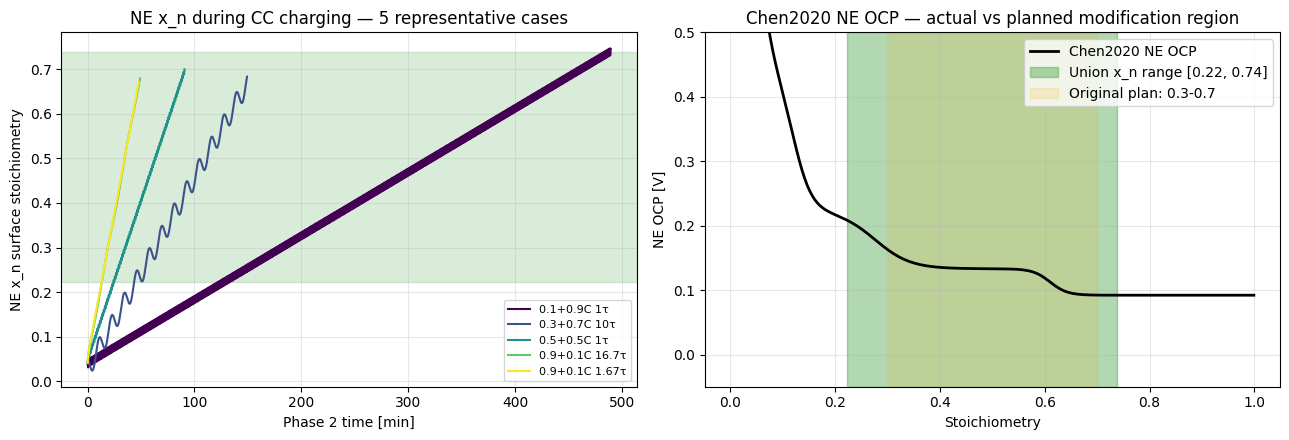


✓ Saved: data/day12_xn_range_probe.csv


In [8]:
# Day 12 Cell 2.5 v2 — Probe NE x_n trajectory across multiple representative cases
# Goal: find UNION of x_n ranges that 24-case CC phase covers
# This determines OCP modification window that's relevant for ALL ablations

import pybamm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import cumulative_trapezoid
from pathlib import Path

repo = Path("/Users/louislu/pybamm-dcac-superimposed")

# Pick 4 representative cases spanning DC-rate range (DC=0.1, 0.3, 0.5, 0.9)
probe_cases = [
    (0.1, 0.9, 0.01430, "0.1+0.9C 1τ", "high κ, low DC"),
    (0.3, 0.7, 0.00143, "0.3+0.7C 10τ", "moderate κ"),
    (0.5, 0.5, 0.01430, "0.5+0.5C 1τ", "balanced"),
    (0.9, 0.1, 0.00086, "0.9+0.1C 16.7τ", "low κ, high DC, slow AC"),  # row 22 family
]

# Plus the actual row 22 (worst case Q_CC_end)
probe_cases.append((0.9, 0.1, 0.00860, "0.9+0.1C 1.67τ", "row 22, min Q_CC_end"))

print("=" * 90)
print("Probing NE x_n trajectories across 5 representative cases")
print("=" * 90)

ne_ocp_chen = None
all_xn_ranges = []
all_xn_traj = []

for DC, AC, f_Hz, label, descr in probe_cases:
    # Build experiment
    cap_Ah = 5.0
    I_DC_A = -abs(DC) * cap_Ah
    A_A = AC * cap_Ah
    
    def dc_ac_current(variables):
        t_relative = variables["Time [s]"] - 1.0
        return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)
    
    dcac_step = pybamm.step.CustomStepExplicit(
        dc_ac_current, termination="4.2V", direction="charge"
    )
    experiment = pybamm.Experiment([
        "Rest for 1 second", dcac_step, "Hold at 4.2V until C/68",
    ])
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = 293.15
    pv["Initial temperature [K]"] = 293.15
    pv.set_initial_state(0.01688)
    if ne_ocp_chen is None:
        ne_ocp_chen = pv["Negative electrode OCP [V]"]
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    sol = sim.solve()
    phase2 = sol.cycles[1]; phase3 = sol.cycles[2]
    
    # NE surface stoichiometry
    c_n_surf = phase2["X-averaged negative particle surface concentration [mol.m-3]"].entries
    c_n_max = pv["Maximum concentration in negative electrode [mol.m-3]"]
    x_n_surf = c_n_surf / c_n_max
    
    # Q trajectory aligned to phase 2 time
    t_chg = np.concatenate([phase2.t, phase3.t])
    I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
    _, ui = np.unique(t_chg, return_index=True)
    ui = np.sort(ui)
    t_chg = t_chg[ui] - t_chg[ui][0]
    I_chg = I_chg[ui]
    Q_mAh = -cumulative_trapezoid(I_chg, t_chg, initial=0) / 3600.0 * 1000.0
    
    t_phase2_in_chg = phase2.t - phase2.t[0]
    Q_at_phase2 = np.interp(t_phase2_in_chg, t_chg, Q_mAh)
    cc_time_s = phase2.t[-1] - phase2.t[0]
    Q_at_CC_end = np.interp(cc_time_s, t_chg, Q_mAh)
    
    # x_n at Q20=1025 and at Q_CC_end
    Q_target_lo = 1025.0
    Q_target_hi_eff = max(min(Q_at_CC_end - 50, 4101), 2050)
    
    if Q_target_lo > Q_at_phase2.max():
        x_n_at_Qlo = None
    else:
        idx = np.argmax(Q_at_phase2 >= Q_target_lo)
        if idx > 0:
            frac = (Q_target_lo - Q_at_phase2[idx-1]) / (Q_at_phase2[idx] - Q_at_phase2[idx-1])
            x_n_at_Qlo = x_n_surf[idx-1] + frac * (x_n_surf[idx] - x_n_surf[idx-1])
        else:
            x_n_at_Qlo = x_n_surf[idx]
    
    if Q_target_hi_eff > Q_at_phase2.max():
        x_n_at_Qhi = x_n_surf[-1]  # use end of phase 2
    else:
        idx = np.argmax(Q_at_phase2 >= Q_target_hi_eff)
        if idx > 0:
            frac = (Q_target_hi_eff - Q_at_phase2[idx-1]) / (Q_at_phase2[idx] - Q_at_phase2[idx-1])
            x_n_at_Qhi = x_n_surf[idx-1] + frac * (x_n_surf[idx] - x_n_surf[idx-1])
        else:
            x_n_at_Qhi = x_n_surf[idx]
    
    all_xn_ranges.append({
        'condition': label, 'descr': descr,
        'Q_CC_end_mAh': Q_at_CC_end,
        'Q_window_lo': Q_target_lo, 'Q_window_hi': Q_target_hi_eff,
        'x_n_lo': x_n_at_Qlo, 'x_n_hi': x_n_at_Qhi,
    })
    all_xn_traj.append({
        'label': label, 't_min': t_phase2_in_chg/60, 'x_n': x_n_surf, 'Q_mAh': Q_at_phase2
    })
    
    print(f"  {label:<20} ({descr}): Q_CC_end={Q_at_CC_end:.0f} mAh, "
          f"x_n range [{x_n_at_Qlo:.3f}, {x_n_at_Qhi:.3f}]")

# Compute UNION x_n range across all probed cases
all_xn_lo = [r['x_n_lo'] for r in all_xn_ranges if r['x_n_lo'] is not None]
all_xn_hi = [r['x_n_hi'] for r in all_xn_ranges if r['x_n_hi'] is not None]

xn_union_lo = min(all_xn_lo)
xn_union_hi = max(all_xn_hi)

print()
print("=" * 90)
print(f"UNION x_n range across 5 probed cases: [{xn_union_lo:.3f}, {xn_union_hi:.3f}]")
print("=" * 90)
print(f"\nA1/A2 OCP modification window recommendations:")
print(f"  Conservative (full union):  sto_lo={xn_union_lo:.2f}, sto_hi={xn_union_hi:.2f}")
print(f"  Restrictive (high-x_n):     sto_lo=0.40, sto_hi={xn_union_hi:.2f}  (only late CC)")
print(f"  Compare original plan (0.3-0.7):  ", end="")
if 0.3 <= xn_union_lo and xn_union_hi <= 0.7:
    print("union FITS inside 0.3-0.7 ✓")
else:
    print(f"union {xn_union_lo:.2f}-{xn_union_hi:.2f} differs from 0.3-0.7")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(all_xn_traj)))
for i, traj in enumerate(all_xn_traj):
    ax.plot(traj['t_min'], traj['x_n'], color=colors[i], lw=1.5, label=traj['label'])
ax.set_xlabel('Phase 2 time [min]')
ax.set_ylabel('NE x_n surface stoichiometry')
ax.set_title('NE x_n during CC charging — 5 representative cases')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.axhspan(xn_union_lo, xn_union_hi, alpha=0.15, color='green',
           label=f'union range [{xn_union_lo:.2f}, {xn_union_hi:.2f}]')

ax = axes[1]
sto_grid = np.linspace(0.001, 0.999, 200)
v_chen = np.array([float(ne_ocp_chen(s)) for s in sto_grid])
ax.plot(sto_grid, v_chen, 'k-', lw=2, label='Chen2020 NE OCP')
ax.axvspan(xn_union_lo, xn_union_hi, alpha=0.3, color='green',
           label=f'Union x_n range [{xn_union_lo:.2f}, {xn_union_hi:.2f}]')
ax.axvspan(0.3, 0.7, alpha=0.15, color='orange', label='Original plan: 0.3-0.7')
ax.set_xlabel('Stoichiometry')
ax.set_ylabel('NE OCP [V]')
ax.set_title('Chen2020 NE OCP — actual vs planned modification region')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 0.5)

plt.tight_layout()
plt.savefig('../figures/day12_xn_trajectory_5case_probe.png', dpi=100)
plt.show()

# Save
df_xn = pd.DataFrame(all_xn_ranges)
df_xn.to_csv(repo / "data" / "day12_xn_range_probe.csv", index=False)
print(f"\n✓ Saved: data/day12_xn_range_probe.csv")

Sanity test on float input (sto=0.5):
  Chen2020 baseline:    0.1331 V
  A1 steepen ×3         : 0.0197 V
  A2a notch +0.02V      : 0.1531 V
  A2b notch +0.05V      : 0.1831 V


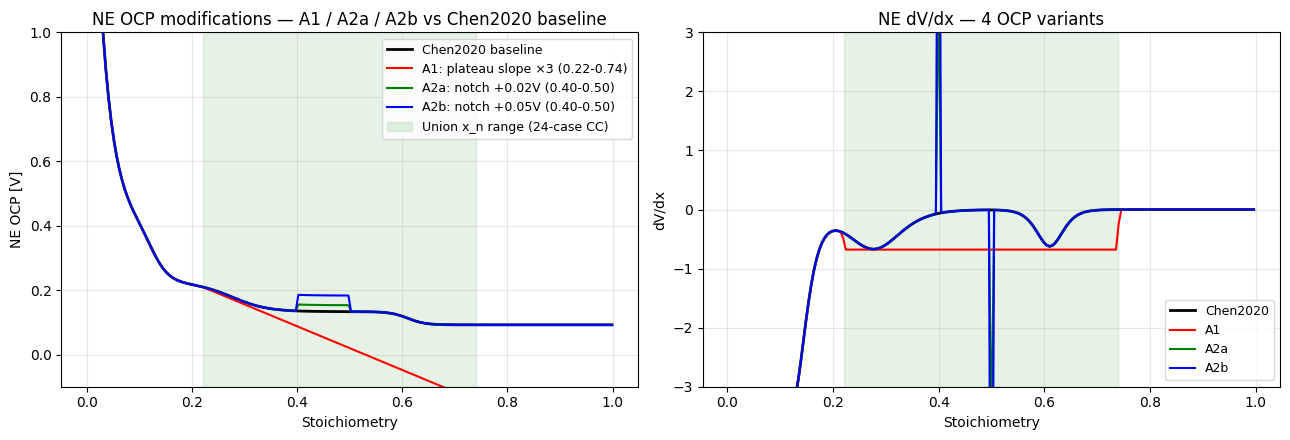


V_init sanity check at SOC=0.01688 under each modification
Reference X5-A target V_init: 2.82V
  Chen2020 baseline     : V_init = 2.8206V  (Δ +0.0006V, drift -0.00000V) ✓
  A1: plateau ×3        : V_init = 2.7574V  (Δ -0.0626V, drift -0.00000V) ⚠ bisect
  A2a: notch +0.02V     : V_init = 2.8206V  (Δ +0.0006V, drift -0.00000V) ✓
  A2b: notch +0.05V     : V_init = 2.8206V  (Δ +0.0006V, drift -0.00000V) ✓


In [9]:
# Day 12 Cell 3 — Final NE OCP modification definitions with union x_n boundary
# Modifications follow the ruthless mentor framing:
#   A1: Plateau-slope amplification (multiply local dV/dx by 3.0)
#   A2a: Local notch +0.02 V (gentle stress test)
#   A2b: Local notch +0.05 V (aggressive stress test)
# Window for A1: sto 0.22-0.74 (full union x_n range across 24 cases)
# Window for A2: sto 0.40-0.50 (mid-plateau, where dV/dx ≈ 0 in baseline)

import pybamm
import numpy as np
import matplotlib.pyplot as plt

pv_ref = pybamm.ParameterValues("Chen2020")
ne_ocp_chen = pv_ref["Negative electrode OCP [V]"]


def make_steepen_plateau_ocp(multiplier=3.0, sto_lo=0.22, sto_hi=0.74):
    """A1: plateau-slope amplification.
    Symbolic-compatible via Heaviside arithmetic (cond * a + (1-cond) * b).
    """
    v_lo_ref = float(ne_ocp_chen(sto_lo))
    v_hi_ref = float(ne_ocp_chen(sto_hi))
    dv_orig = v_hi_ref - v_lo_ref
    dv_new = dv_orig * multiplier
    v_hi_new = v_lo_ref + dv_new
    offset_post = v_hi_new - v_hi_ref
    
    def modified_ocp(sto):
        v_orig = ne_ocp_chen(sto)
        v_in_window = v_lo_ref + (sto - sto_lo) / (sto_hi - sto_lo) * dv_new
        v_post = v_orig + offset_post
        in_window = (sto >= sto_lo) * (sto <= sto_hi)
        post_window = sto > sto_hi
        pre_window = sto < sto_lo
        return pre_window * v_orig + in_window * v_in_window + post_window * v_post
    
    return modified_ocp


def make_notch_ocp(shift_V=0.02, sto_lo=0.40, sto_hi=0.50):
    """A2: local notch."""
    def modified_ocp(sto):
        v_orig = ne_ocp_chen(sto)
        in_notch = (sto >= sto_lo) * (sto <= sto_hi)
        return v_orig + shift_V * in_notch
    return modified_ocp


# Build 3 modifications + baseline reference
ocp_A1  = make_steepen_plateau_ocp(multiplier=3.0, sto_lo=0.22, sto_hi=0.74)
ocp_A2a = make_notch_ocp(shift_V=0.02, sto_lo=0.40, sto_hi=0.50)
ocp_A2b = make_notch_ocp(shift_V=0.05, sto_lo=0.40, sto_hi=0.50)

# === Sanity test on float input ===
print("Sanity test on float input (sto=0.5):")
print(f"  Chen2020 baseline:    {float(ne_ocp_chen(0.5)):.4f} V")
for label, fn in [("A1 steepen ×3", ocp_A1), ("A2a notch +0.02V", ocp_A2a), ("A2b notch +0.05V", ocp_A2b)]:
    try:
        v = fn(0.5)
        if hasattr(v, '__float__'): v = float(v)
        print(f"  {label:<22}: {v:.4f} V")
    except Exception as e:
        print(f"  {label:<22}: {type(e).__name__}: {e}")

# === Plot 4 OCP curves (baseline + 3 modifications) ===
sto_grid = np.linspace(0.001, 0.999, 200)
v_chen = np.array([float(ne_ocp_chen(s)) for s in sto_grid])
v_A1  = np.array([float(ocp_A1(s))  for s in sto_grid])
v_A2a = np.array([float(ocp_A2a(s)) for s in sto_grid])
v_A2b = np.array([float(ocp_A2b(s)) for s in sto_grid])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(sto_grid, v_chen, 'k-', lw=2, label='Chen2020 baseline')
ax.plot(sto_grid, v_A1,  'r-', lw=1.5, label='A1: plateau slope ×3 (0.22-0.74)')
ax.plot(sto_grid, v_A2a, 'g-', lw=1.5, label='A2a: notch +0.02V (0.40-0.50)')
ax.plot(sto_grid, v_A2b, 'b-', lw=1.5, label='A2b: notch +0.05V (0.40-0.50)')
ax.axvspan(0.22, 0.74, alpha=0.1, color='green', label='Union x_n range (24-case CC)')
ax.set_xlabel('Stoichiometry'); ax.set_ylabel('NE OCP [V]')
ax.set_title('NE OCP modifications — A1 / A2a / A2b vs Chen2020 baseline')
ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-0.1, 1.0)

ax = axes[1]
sto_mid = (sto_grid[:-1] + sto_grid[1:]) / 2
ax.plot(sto_mid, np.diff(v_chen)/np.diff(sto_grid), 'k-', lw=2, label='Chen2020')
ax.plot(sto_mid, np.diff(v_A1)/np.diff(sto_grid),  'r-', lw=1.5, label='A1')
ax.plot(sto_mid, np.diff(v_A2a)/np.diff(sto_grid), 'g-', lw=1.5, label='A2a')
ax.plot(sto_mid, np.diff(v_A2b)/np.diff(sto_grid), 'b-', lw=1.5, label='A2b')
ax.axvspan(0.22, 0.74, alpha=0.1, color='green')
ax.set_xlabel('Stoichiometry'); ax.set_ylabel('dV/dx')
ax.set_title('NE dV/dx — 4 OCP variants')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-3, 3)
plt.tight_layout()
plt.savefig('../figures/day12_ocp_modifications_v2.png', dpi=100)
plt.show()

# === V_init sanity check ===
print()
print("=" * 70)
print("V_init sanity check at SOC=0.01688 under each modification")
print("Reference X5-A target V_init: 2.82V")
print("=" * 70)

ocp_variants = {
    "Chen2020 baseline": ne_ocp_chen,
    "A1: plateau ×3":    ocp_A1,
    "A2a: notch +0.02V": ocp_A2a,
    "A2b: notch +0.05V": ocp_A2b,
}

for label, ocp_fn in ocp_variants.items():
    pv_test = pybamm.ParameterValues("Chen2020")
    pv_test["Ambient temperature [K]"] = 293.15
    pv_test["Initial temperature [K]"] = 293.15
    pv_test["Negative electrode OCP [V]"] = ocp_fn
    pv_test.set_initial_state(0.01688)
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    sim = pybamm.Simulation(model, parameter_values=pv_test,
                            experiment=pybamm.Experiment(["Rest for 1 second"]))
    try:
        sol = sim.solve()
        v_init = float(sol["Voltage [V]"].entries[0])
        v_drift = float(sol["Voltage [V]"].entries[-1] - sol["Voltage [V]"].entries[0])
        flag = "✓" if abs(v_init - 2.82) < 0.05 else "⚠ bisect"
        print(f"  {label:<22}: V_init = {v_init:.4f}V  (Δ {v_init-2.82:+.4f}V, drift {v_drift:+.5f}V) {flag}")
    except Exception as e:
        print(f"  {label:<22}: FAILED — {type(e).__name__}: {str(e)[:100]}")

Sanity test on float input:
  sto=0.10: baseline=0.4065V  A1=0.4065V (Δ=+0.0000)  A2a=0.4065V (Δ=+0.0000)  A2b=0.4065V (Δ=+0.0000)
  sto=0.30: baseline=0.1630V  A1=0.1779V (Δ=+0.0149)  A2a=0.1630V (Δ=+0.0000)  A2b=0.1630V (Δ=+0.0000)
  sto=0.45: baseline=0.1335V  A1=0.1337V (Δ=+0.0002)  A2a=0.1535V (Δ=+0.0200)  A2b=0.1835V (Δ=+0.0500)
  sto=0.48: baseline=0.1332V  A1=0.1332V (Δ=+0.0000)  A2a=0.1483V (Δ=+0.0151)  A2b=0.1710V (Δ=+0.0377)
  sto=0.60: baseline=0.1188V  A1=0.1115V (Δ=-0.0072)  A2a=0.1188V (Δ=+0.0000)  A2b=0.1188V (Δ=+0.0000)
  sto=0.74: baseline=0.0920V  A1=0.0714V (Δ=-0.0206)  A2a=0.0920V (Δ=+0.0000)  A2b=0.0920V (Δ=+0.0000)
  sto=0.85: baseline=0.0920V  A1=0.0920V (Δ=+0.0000)  A2a=0.0920V (Δ=+0.0000)  A2b=0.0920V (Δ=+0.0000)


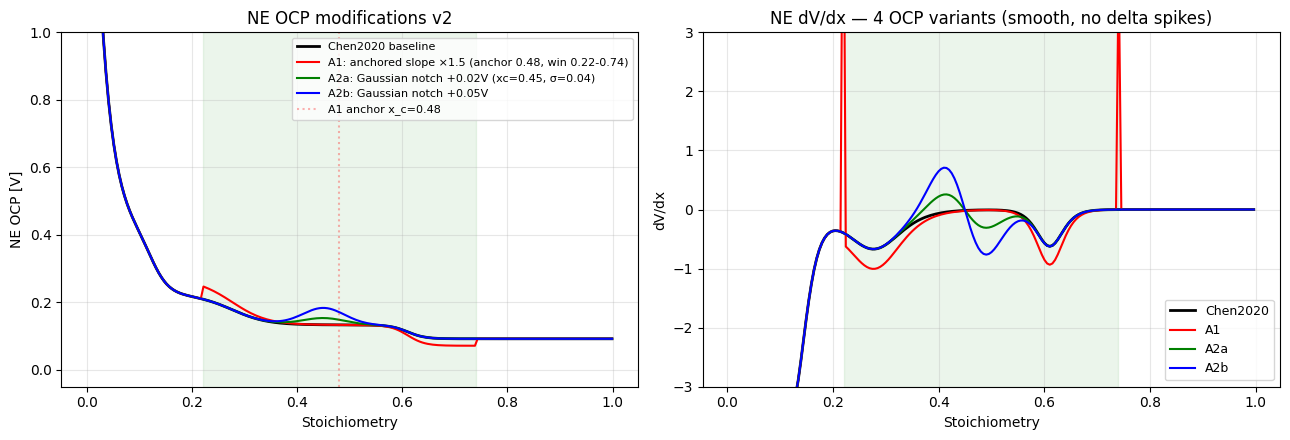


V_init sanity check at SOC=0.01688 (target 2.82V)
  Chen2020 baseline     : V_init = 2.8206V  (Δ +0.0006V) ✓
  A1: anchored ×1.5     : V_init = 2.8206V  (Δ +0.0006V) ✓
  A2a: notch +0.02V     : V_init = 2.8206V  (Δ +0.0006V) ✓
  A2b: notch +0.05V     : V_init = 2.8206V  (Δ +0.0006V) ✓


In [11]:
# Day 12 Cell 3 v2 (patched) — anchored slope amp + Gaussian notch with safe eval

import pybamm
import numpy as np
import matplotlib.pyplot as plt

pv_ref = pybamm.ParameterValues("Chen2020")
ne_ocp_chen = pv_ref["Negative electrode OCP [V]"]


def make_anchored_slope_amp_ocp(s=1.5, x_c=0.48, sto_lo=0.22, sto_hi=0.74):
    v_c = float(ne_ocp_chen(x_c))
    def modified_ocp(sto):
        v_orig = ne_ocp_chen(sto)
        v_in_window = v_c + s * (v_orig - v_c)
        in_window = (sto >= sto_lo) * (sto <= sto_hi)
        return in_window * v_in_window + (1 - in_window) * v_orig
    return modified_ocp


def make_gaussian_notch_ocp(amplitude_V=0.02, x_c=0.45, sigma=0.04):
    def modified_ocp(sto):
        v_orig = ne_ocp_chen(sto)
        gaussian_bump = amplitude_V * pybamm.exp(-((sto - x_c) ** 2) / (2 * sigma ** 2))
        return v_orig + gaussian_bump
    return modified_ocp


def evaluate_ocp(ocp_fn, sto_val):
    """Safely evaluate OCP fn on float, handling pybamm.Scalar return types."""
    result = ocp_fn(sto_val)
    if hasattr(result, 'evaluate'):
        return float(result.evaluate())
    return float(result)


ocp_A1  = make_anchored_slope_amp_ocp(s=1.5, x_c=0.48, sto_lo=0.22, sto_hi=0.74)
ocp_A2a = make_gaussian_notch_ocp(amplitude_V=0.02, x_c=0.45, sigma=0.04)
ocp_A2b = make_gaussian_notch_ocp(amplitude_V=0.05, x_c=0.45, sigma=0.04)

# === Sanity test on float input ===
print("Sanity test on float input:")
for sto_test in [0.1, 0.30, 0.45, 0.48, 0.60, 0.74, 0.85]:
    v_base = evaluate_ocp(ne_ocp_chen, sto_test)
    v_a1   = evaluate_ocp(ocp_A1,  sto_test)
    v_a2a  = evaluate_ocp(ocp_A2a, sto_test)
    v_a2b  = evaluate_ocp(ocp_A2b, sto_test)
    print(f"  sto={sto_test:.2f}: baseline={v_base:.4f}V  "
          f"A1={v_a1:.4f}V (Δ={v_a1-v_base:+.4f})  "
          f"A2a={v_a2a:.4f}V (Δ={v_a2a-v_base:+.4f})  "
          f"A2b={v_a2b:.4f}V (Δ={v_a2b-v_base:+.4f})")

# === Plot ===
sto_grid = np.linspace(0.001, 0.999, 200)
v_chen = np.array([evaluate_ocp(ne_ocp_chen, s) for s in sto_grid])
v_A1   = np.array([evaluate_ocp(ocp_A1,  s) for s in sto_grid])
v_A2a  = np.array([evaluate_ocp(ocp_A2a, s) for s in sto_grid])
v_A2b  = np.array([evaluate_ocp(ocp_A2b, s) for s in sto_grid])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(sto_grid, v_chen, 'k-', lw=2, label='Chen2020 baseline')
ax.plot(sto_grid, v_A1,   'r-', lw=1.5, label='A1: anchored slope ×1.5 (anchor 0.48, win 0.22-0.74)')
ax.plot(sto_grid, v_A2a,  'g-', lw=1.5, label='A2a: Gaussian notch +0.02V (xc=0.45, σ=0.04)')
ax.plot(sto_grid, v_A2b,  'b-', lw=1.5, label='A2b: Gaussian notch +0.05V')
ax.axvspan(0.22, 0.74, alpha=0.08, color='green')
ax.axvline(0.48, alpha=0.3, color='r', ls=':', label='A1 anchor x_c=0.48')
ax.set_xlabel('Stoichiometry'); ax.set_ylabel('NE OCP [V]')
ax.set_title('NE OCP modifications v2')
ax.legend(loc='upper right', fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.0)

ax = axes[1]
sto_mid = (sto_grid[:-1] + sto_grid[1:]) / 2
ax.plot(sto_mid, np.diff(v_chen)/np.diff(sto_grid), 'k-', lw=2, label='Chen2020')
ax.plot(sto_mid, np.diff(v_A1)/np.diff(sto_grid),   'r-', lw=1.5, label='A1')
ax.plot(sto_mid, np.diff(v_A2a)/np.diff(sto_grid),  'g-', lw=1.5, label='A2a')
ax.plot(sto_mid, np.diff(v_A2b)/np.diff(sto_grid),  'b-', lw=1.5, label='A2b')
ax.axvspan(0.22, 0.74, alpha=0.08, color='green')
ax.set_xlabel('Stoichiometry'); ax.set_ylabel('dV/dx')
ax.set_title('NE dV/dx — 4 OCP variants (smooth, no delta spikes)')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-3, 3)
plt.tight_layout()
plt.savefig('../figures/day12_ocp_modifications_v3.png', dpi=100)
plt.show()

# === V_init check ===
print()
print("=" * 70)
print("V_init sanity check at SOC=0.01688 (target 2.82V)")
print("=" * 70)

for label, ocp_fn in [
    ("Chen2020 baseline",  ne_ocp_chen),
    ("A1: anchored ×1.5",  ocp_A1),
    ("A2a: notch +0.02V",  ocp_A2a),
    ("A2b: notch +0.05V",  ocp_A2b),
]:
    pv_test = pybamm.ParameterValues("Chen2020")
    pv_test["Ambient temperature [K]"] = 293.15
    pv_test["Initial temperature [K]"] = 293.15
    pv_test["Negative electrode OCP [V]"] = ocp_fn
    pv_test.set_initial_state(0.01688)
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    sim = pybamm.Simulation(model, parameter_values=pv_test,
                            experiment=pybamm.Experiment(["Rest for 1 second"]))
    try:
        sol = sim.solve()
        v_init = float(sol["Voltage [V]"].entries[0])
        flag = "✓" if abs(v_init - 2.82) < 0.05 else "⚠ bisect"
        print(f"  {label:<22}: V_init = {v_init:.4f}V  (Δ {v_init-2.82:+.4f}V) {flag}")
    except Exception as e:
        print(f"  {label:<22}: FAILED — {type(e).__name__}: {str(e)[:100]}")

Sanity test on float input (A1 with taper_width=0.03):
  sto=0.10: baseline=0.4065V  A1=0.4065V (Δ=+0.0000)  A2a=0.4065V (Δ=+0.0000)  A2b=0.4065V (Δ=+0.0000)
  sto=0.21: baseline=0.2134V  A1=0.2134V (Δ=+0.0000)  A2a=0.2134V (Δ=+0.0000)  A2b=0.2134V (Δ=+0.0000)
  sto=0.22: baseline=0.2096V  A1=0.2096V (Δ=+0.0000)  A2a=0.2096V (Δ=+0.0000)  A2b=0.2096V (Δ=+0.0000)
  sto=0.25: baseline=0.1951V  A1=0.2260V (Δ=+0.0309)  A2a=0.1951V (Δ=+0.0000)  A2b=0.1951V (Δ=+0.0000)
  sto=0.30: baseline=0.1630V  A1=0.1779V (Δ=+0.0149)  A2a=0.1630V (Δ=+0.0000)  A2b=0.1630V (Δ=+0.0000)
  sto=0.45: baseline=0.1335V  A1=0.1337V (Δ=+0.0002)  A2a=0.1535V (Δ=+0.0200)  A2b=0.1835V (Δ=+0.0500)
  sto=0.48: baseline=0.1332V  A1=0.1332V (Δ=+0.0000)  A2a=0.1483V (Δ=+0.0151)  A2b=0.1710V (Δ=+0.0377)
  sto=0.60: baseline=0.1188V  A1=0.1115V (Δ=-0.0072)  A2a=0.1188V (Δ=+0.0000)  A2b=0.1188V (Δ=+0.0000)
  sto=0.71: baseline=0.0921V  A1=0.0716V (Δ=-0.0205)  A2a=0.0921V (Δ=+0.0000)  A2b=0.0921V (Δ=+0.0000)
  sto=0.74: baseli

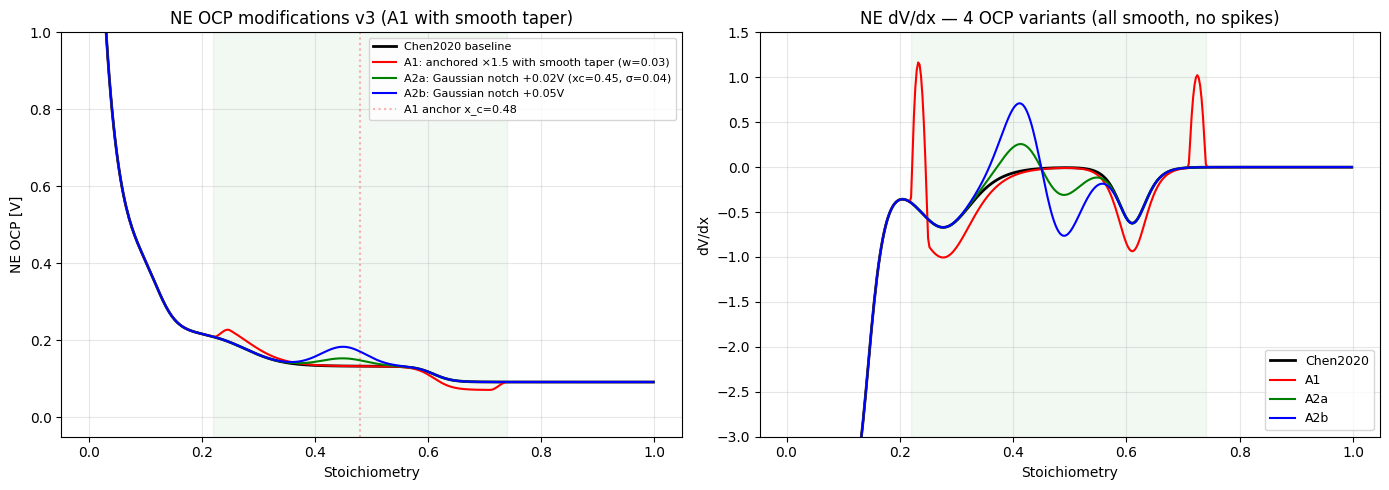


V_init sanity check at SOC=0.01688 (target 2.82V)
  Chen2020 baseline         : V_init = 2.8206V  (Δ +0.0006V) ✓
  A1: anchored ×1.5 taper   : V_init = 2.8206V  (Δ +0.0006V) ✓
  A2a: notch +0.02V         : V_init = 2.8206V  (Δ +0.0006V) ✓
  A2b: notch +0.05V         : V_init = 2.8206V  (Δ +0.0006V) ✓

Max A1 perturbation in plateau region (sto 0.22-0.74)
  max |ΔU_A1| in window: 31.13 mV
  Criterion 4: 10-25 mV → ⚠ too large (31.1 mV) — may dominate physics


In [12]:
# Day 12 Cell 3 v3 — A1 anchored slope amp + smooth taper at boundaries
# A1 = U_base + w(x) · ΔU_slope
# w(x) = smoothstep transitioning 0→1 over [sto_lo, sto_lo+taper_width]
#                           = 1 in central region
#                           = smoothstep 1→0 over [sto_hi-taper_width, sto_hi]
# A2a/A2b: unchanged Gaussian notches

import pybamm
import numpy as np
import matplotlib.pyplot as plt

pv_ref = pybamm.ParameterValues("Chen2020")
ne_ocp_chen = pv_ref["Negative electrode OCP [V]"]


def smoothstep(x, edge_lo, edge_hi):
    """Cubic Hermite smoothstep: 0 below edge_lo, 1 above edge_hi, smooth in between.
    Compatible with both numpy floats and PyBaMM symbolic input via arithmetic only."""
    t = (x - edge_lo) / (edge_hi - edge_lo)
    # Clamp to [0, 1] using min/max via arithmetic
    t_clamped = t * (t >= 0) * (t <= 1) + (t > 1) * 1.0  # below 0 stays 0 by (t >= 0)
    # 3t² - 2t³
    return t_clamped * t_clamped * (3.0 - 2.0 * t_clamped)


def make_anchored_slope_amp_smooth_ocp(s=1.5, x_c=0.48, sto_lo=0.22, sto_hi=0.74,
                                        taper_width=0.03):
    """A1: anchored slope amp with smooth taper at window boundaries.
    
    U_mod(x) = U_base(x) + w(x) · ΔU_slope(x)
    where ΔU_slope(x) = U_c + s·(U_base(x) - U_c) - U_base(x) = (s-1)·(U_base(x) - U_c)
    and w(x) is the tapered window:
      0 for x < sto_lo
      smoothstep 0→1 over [sto_lo, sto_lo + taper_width]
      1 over [sto_lo + taper_width, sto_hi - taper_width]
      smoothstep 1→0 over [sto_hi - taper_width, sto_hi]
      0 for x > sto_hi
    
    At x=x_c (anchor): ΔU_slope = 0 → U_mod = U_base.
    Outside window: w=0 → U_mod = U_base.
    No step, no V_init drift.
    """
    v_c = float(ne_ocp_chen(x_c))
    sto_lo_inner = sto_lo + taper_width
    sto_hi_inner = sto_hi - taper_width
    
    def window_fn(sto):
        # rising edge: 0 below sto_lo, smoothstep up to 1 at sto_lo + taper_width
        rising = smoothstep(sto, sto_lo, sto_lo_inner)
        # falling edge: 1 below sto_hi - taper_width, smoothstep down to 0 at sto_hi
        falling = 1.0 - smoothstep(sto, sto_hi_inner, sto_hi)
        # combined: only nonzero in [sto_lo, sto_hi]; value = min(rising, falling)
        # implemented as rising × falling × indicator (rising and falling both ≥ 0 here)
        # but cleaner: 0 outside window, rising in lo-taper, 1 in middle, falling in hi-taper
        in_window = (sto >= sto_lo) * (sto <= sto_hi)
        # within window: at lo-taper region rising < 1, falling = 1 → use rising
        #                in middle: rising = falling = 1 → use either
        #                at hi-taper region: rising = 1, falling < 1 → use falling
        # so combined = rising × falling works for cubic smoothstep (both go to 1 in middle)
        return in_window * rising * falling
    
    def modified_ocp(sto):
        v_orig = ne_ocp_chen(sto)
        delta_u_slope = (s - 1.0) * (v_orig - v_c)
        w = window_fn(sto)
        return v_orig + w * delta_u_slope
    
    return modified_ocp


def make_gaussian_notch_ocp(amplitude_V=0.02, x_c=0.45, sigma=0.04):
    def modified_ocp(sto):
        v_orig = ne_ocp_chen(sto)
        gaussian_bump = amplitude_V * pybamm.exp(-((sto - x_c) ** 2) / (2 * sigma ** 2))
        return v_orig + gaussian_bump
    return modified_ocp


def evaluate_ocp(ocp_fn, sto_val):
    result = ocp_fn(sto_val)
    if hasattr(result, 'evaluate'):
        return float(result.evaluate())
    return float(result)


ocp_A1  = make_anchored_slope_amp_smooth_ocp(s=1.5, x_c=0.48,
                                              sto_lo=0.22, sto_hi=0.74,
                                              taper_width=0.03)
ocp_A2a = make_gaussian_notch_ocp(amplitude_V=0.02, x_c=0.45, sigma=0.04)
ocp_A2b = make_gaussian_notch_ocp(amplitude_V=0.05, x_c=0.45, sigma=0.04)

# === Sanity test on float input ===
print("Sanity test on float input (A1 with taper_width=0.03):")
for sto_test in [0.10, 0.21, 0.22, 0.25, 0.30, 0.45, 0.48, 0.60, 0.71, 0.74, 0.78, 0.85]:
    v_base = evaluate_ocp(ne_ocp_chen, sto_test)
    v_a1   = evaluate_ocp(ocp_A1,  sto_test)
    v_a2a  = evaluate_ocp(ocp_A2a, sto_test)
    v_a2b  = evaluate_ocp(ocp_A2b, sto_test)
    print(f"  sto={sto_test:.2f}: baseline={v_base:.4f}V  "
          f"A1={v_a1:.4f}V (Δ={v_a1-v_base:+.4f})  "
          f"A2a={v_a2a:.4f}V (Δ={v_a2a-v_base:+.4f})  "
          f"A2b={v_a2b:.4f}V (Δ={v_a2b-v_base:+.4f})")

# === Plot ===
sto_grid = np.linspace(0.001, 0.999, 400)  # finer grid to see taper
v_chen = np.array([evaluate_ocp(ne_ocp_chen, s) for s in sto_grid])
v_A1   = np.array([evaluate_ocp(ocp_A1,  s) for s in sto_grid])
v_A2a  = np.array([evaluate_ocp(ocp_A2a, s) for s in sto_grid])
v_A2b  = np.array([evaluate_ocp(ocp_A2b, s) for s in sto_grid])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(sto_grid, v_chen, 'k-', lw=2, label='Chen2020 baseline')
ax.plot(sto_grid, v_A1,   'r-', lw=1.5, label='A1: anchored ×1.5 with smooth taper (w=0.03)')
ax.plot(sto_grid, v_A2a,  'g-', lw=1.5, label='A2a: Gaussian notch +0.02V (xc=0.45, σ=0.04)')
ax.plot(sto_grid, v_A2b,  'b-', lw=1.5, label='A2b: Gaussian notch +0.05V')
ax.axvspan(0.22, 0.74, alpha=0.05, color='green')
ax.axvline(0.48, alpha=0.3, color='r', ls=':', label='A1 anchor x_c=0.48')
ax.set_xlabel('Stoichiometry'); ax.set_ylabel('NE OCP [V]')
ax.set_title('NE OCP modifications v3 (A1 with smooth taper)')
ax.legend(loc='upper right', fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.0)

ax = axes[1]
sto_mid = (sto_grid[:-1] + sto_grid[1:]) / 2
ax.plot(sto_mid, np.diff(v_chen)/np.diff(sto_grid), 'k-', lw=2, label='Chen2020')
ax.plot(sto_mid, np.diff(v_A1)/np.diff(sto_grid),   'r-', lw=1.5, label='A1')
ax.plot(sto_mid, np.diff(v_A2a)/np.diff(sto_grid),  'g-', lw=1.5, label='A2a')
ax.plot(sto_mid, np.diff(v_A2b)/np.diff(sto_grid),  'b-', lw=1.5, label='A2b')
ax.axvspan(0.22, 0.74, alpha=0.05, color='green')
ax.set_xlabel('Stoichiometry'); ax.set_ylabel('dV/dx')
ax.set_title('NE dV/dx — 4 OCP variants (all smooth, no spikes)')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-3, 1.5)
plt.tight_layout()
plt.savefig('../figures/day12_ocp_modifications_v3_tapered.png', dpi=100)
plt.show()

# === V_init check ===
print()
print("=" * 70)
print("V_init sanity check at SOC=0.01688 (target 2.82V)")
print("=" * 70)

for label, ocp_fn in [
    ("Chen2020 baseline",       ne_ocp_chen),
    ("A1: anchored ×1.5 taper", ocp_A1),
    ("A2a: notch +0.02V",       ocp_A2a),
    ("A2b: notch +0.05V",       ocp_A2b),
]:
    pv_test = pybamm.ParameterValues("Chen2020")
    pv_test["Ambient temperature [K]"] = 293.15
    pv_test["Initial temperature [K]"] = 293.15
    pv_test["Negative electrode OCP [V]"] = ocp_fn
    pv_test.set_initial_state(0.01688)
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    sim = pybamm.Simulation(model, parameter_values=pv_test,
                            experiment=pybamm.Experiment(["Rest for 1 second"]))
    try:
        sol = sim.solve()
        v_init = float(sol["Voltage [V]"].entries[0])
        flag = "✓" if abs(v_init - 2.82) < 0.05 else "⚠ bisect"
        print(f"  {label:<26}: V_init = {v_init:.4f}V  (Δ {v_init-2.82:+.4f}V) {flag}")
    except Exception as e:
        print(f"  {label:<26}: FAILED — {type(e).__name__}: {str(e)[:100]}")

# === Max perturbation check (judgment criterion 4) ===
print()
print("=" * 70)
print("Max A1 perturbation in plateau region (sto 0.22-0.74)")
print("=" * 70)
mask_window = (sto_grid >= 0.22) & (sto_grid <= 0.74)
delta_A1_window = np.abs(v_A1[mask_window] - v_chen[mask_window])
print(f"  max |ΔU_A1| in window: {delta_A1_window.max() * 1000:.2f} mV")
print(f"  Criterion 4: 10-25 mV → ", end="")
if 10 < delta_A1_window.max() * 1000 < 25:
    print("✓ in range")
elif delta_A1_window.max() * 1000 < 10:
    print(f"⚠ too small ({delta_A1_window.max()*1000:.1f} mV) — A1 may have negligible effect on sim")
else:
    print(f"⚠ too large ({delta_A1_window.max()*1000:.1f} mV) — may dominate physics")

Sanity test — A1a (s=1.3, taper=0.06) vs A1b (s=1.5, taper=0.03):
  sto  baseline       A1a      ΔA1a       A1b      ΔA1b
-------------------------------------------------------
 0.10    0.4065    0.4065   +0.0000    0.4065   +0.0000
 0.21    0.2134    0.2134   +0.0000    0.2134   +0.0000
 0.22    0.2096    0.2096   +0.0000    0.2096   +0.0000
 0.25    0.1951    0.2043   +0.0093    0.2260   +0.0309
 0.28    0.1758    0.1885   +0.0128    0.1971   +0.0213
 0.30    0.1630    0.1719   +0.0089    0.1779   +0.0149
 0.35    0.1421    0.1448   +0.0027    0.1466   +0.0044
 0.40    0.1352    0.1358   +0.0006    0.1363   +0.0010
 0.45    0.1335    0.1336   +0.0001    0.1337   +0.0002
 0.48    0.1332    0.1332   +0.0000    0.1332   +0.0000
 0.55    0.1320    0.1317   -0.0004    0.1314   -0.0006
 0.60    0.1188    0.1144   -0.0043    0.1115   -0.0072
 0.65    0.0954    0.0840   -0.0114    0.0765   -0.0189
 0.68    0.0926    0.0804   -0.0122    0.0723   -0.0203
 0.71    0.0921    0.0859   -0.0062   

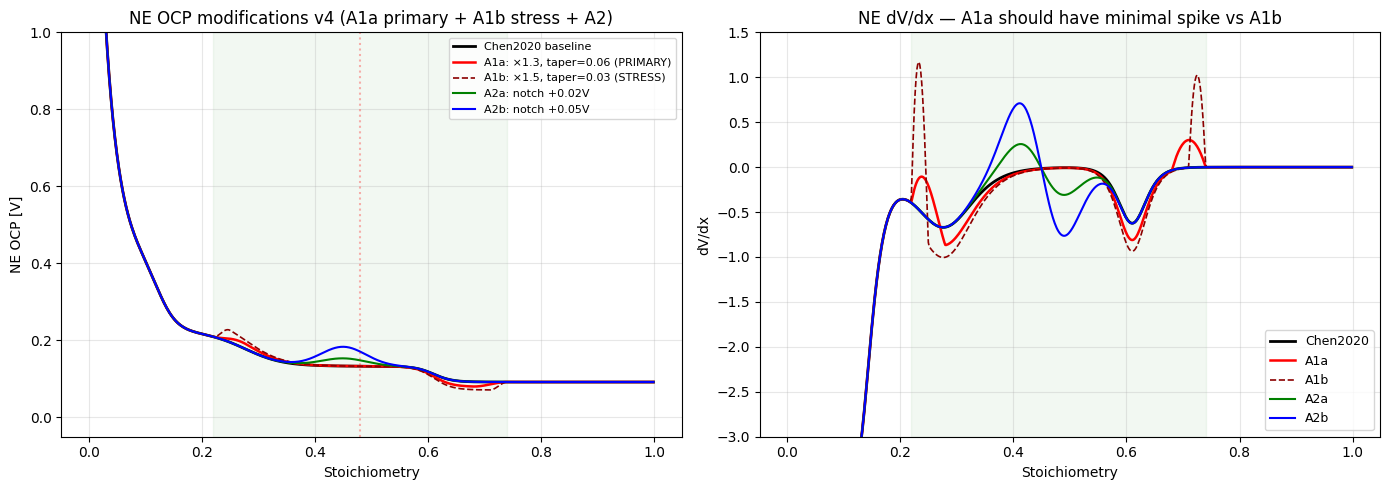


V_init sanity check at SOC=0.01688 (target 2.82V)
  Chen2020 baseline                  : V_init = 2.8206V  (Δ +0.0006V) ✓
  A1a: ×1.3 taper=0.06 (primary)     : V_init = 2.8206V  (Δ +0.0006V) ✓
  A1b: ×1.5 taper=0.03 (stress)      : V_init = 2.8206V  (Δ +0.0006V) ✓
  A2a: notch +0.02V                  : V_init = 2.8206V  (Δ +0.0006V) ✓
  A2b: notch +0.05V                  : V_init = 2.8206V  (Δ +0.0006V) ✓

Max |ΔU| in plateau region (sto 0.22-0.74)
  A1a max |ΔU| in window: 13.69 mV
      Criterion 4 (≤25 mV): ✓ pass
  A1b max |ΔU| in window: 31.08 mV (stress, no criterion)

dV/dx perturbation magnitude (relative to baseline)
  A1a max |Δ(dV/dx)| in window: 0.413 V/unit_sto
  A1b max |Δ(dV/dx)| in window: 1.644 V/unit_sto
  baseline plateau dV/dx ~0 → A1a/A1b spike threshold meaningful only if >>0

BATCH DECISION
  A1a 4-criterion compliance: ✓ READY for batch
  A1b: stress only, runs alongside A1a with same protocol but no criterion 4
  A2a, A2b: ready


In [13]:
# Day 12 Cell 3 v4 — A1a primary (s=1.3, taper=0.06) + A1b stress (s=1.5, taper=0.03)
# A1a/A1b sanity check before any batch sim

import pybamm
import numpy as np
import matplotlib.pyplot as plt

pv_ref = pybamm.ParameterValues("Chen2020")
ne_ocp_chen = pv_ref["Negative electrode OCP [V]"]


def smoothstep(x, edge_lo, edge_hi):
    t = (x - edge_lo) / (edge_hi - edge_lo)
    t_clamped = t * (t >= 0) * (t <= 1) + (t > 1) * 1.0
    return t_clamped * t_clamped * (3.0 - 2.0 * t_clamped)


def make_anchored_slope_amp_smooth_ocp(s=1.3, x_c=0.48, sto_lo=0.22, sto_hi=0.74,
                                        taper_width=0.06):
    v_c = float(ne_ocp_chen(x_c))
    sto_lo_inner = sto_lo + taper_width
    sto_hi_inner = sto_hi - taper_width
    
    def window_fn(sto):
        rising = smoothstep(sto, sto_lo, sto_lo_inner)
        falling = 1.0 - smoothstep(sto, sto_hi_inner, sto_hi)
        in_window = (sto >= sto_lo) * (sto <= sto_hi)
        return in_window * rising * falling
    
    def modified_ocp(sto):
        v_orig = ne_ocp_chen(sto)
        delta_u_slope = (s - 1.0) * (v_orig - v_c)
        w = window_fn(sto)
        return v_orig + w * delta_u_slope
    
    return modified_ocp


def make_gaussian_notch_ocp(amplitude_V=0.02, x_c=0.45, sigma=0.04):
    def modified_ocp(sto):
        v_orig = ne_ocp_chen(sto)
        gaussian_bump = amplitude_V * pybamm.exp(-((sto - x_c) ** 2) / (2 * sigma ** 2))
        return v_orig + gaussian_bump
    return modified_ocp


def evaluate_ocp(ocp_fn, sto_val):
    result = ocp_fn(sto_val)
    if hasattr(result, 'evaluate'):
        return float(result.evaluate())
    return float(result)


# === Build all 4 modifications ===
ocp_A1a = make_anchored_slope_amp_smooth_ocp(s=1.3, x_c=0.48,
                                              sto_lo=0.22, sto_hi=0.74,
                                              taper_width=0.06)
ocp_A1b = make_anchored_slope_amp_smooth_ocp(s=1.5, x_c=0.48,
                                              sto_lo=0.22, sto_hi=0.74,
                                              taper_width=0.03)
ocp_A2a = make_gaussian_notch_ocp(amplitude_V=0.02, x_c=0.45, sigma=0.04)
ocp_A2b = make_gaussian_notch_ocp(amplitude_V=0.05, x_c=0.45, sigma=0.04)

# === Sanity test on float input ===
print("Sanity test — A1a (s=1.3, taper=0.06) vs A1b (s=1.5, taper=0.03):")
print(f"{'sto':>5} {'baseline':>9} {'A1a':>9} {'ΔA1a':>9} {'A1b':>9} {'ΔA1b':>9}")
print("-" * 55)
for sto_test in [0.10, 0.21, 0.22, 0.25, 0.28, 0.30, 0.35, 0.40, 0.45, 0.48,
                 0.55, 0.60, 0.65, 0.68, 0.71, 0.74, 0.78, 0.85]:
    v_base = evaluate_ocp(ne_ocp_chen, sto_test)
    v_a1a  = evaluate_ocp(ocp_A1a, sto_test)
    v_a1b  = evaluate_ocp(ocp_A1b, sto_test)
    print(f"{sto_test:>5.2f} {v_base:>9.4f} {v_a1a:>9.4f} {v_a1a-v_base:>+9.4f} "
          f"{v_a1b:>9.4f} {v_a1b-v_base:>+9.4f}")

# === Plot 5-curve comparison ===
sto_grid = np.linspace(0.001, 0.999, 600)  # very fine
v_chen = np.array([evaluate_ocp(ne_ocp_chen, s) for s in sto_grid])
v_A1a  = np.array([evaluate_ocp(ocp_A1a, s) for s in sto_grid])
v_A1b  = np.array([evaluate_ocp(ocp_A1b, s) for s in sto_grid])
v_A2a  = np.array([evaluate_ocp(ocp_A2a, s) for s in sto_grid])
v_A2b  = np.array([evaluate_ocp(ocp_A2b, s) for s in sto_grid])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(sto_grid, v_chen, 'k-', lw=2, label='Chen2020 baseline')
ax.plot(sto_grid, v_A1a, color='red',     lw=1.8, label='A1a: ×1.3, taper=0.06 (PRIMARY)')
ax.plot(sto_grid, v_A1b, color='darkred', lw=1.2, ls='--', label='A1b: ×1.5, taper=0.03 (STRESS)')
ax.plot(sto_grid, v_A2a, color='green',   lw=1.5, label='A2a: notch +0.02V')
ax.plot(sto_grid, v_A2b, color='blue',    lw=1.5, label='A2b: notch +0.05V')
ax.axvspan(0.22, 0.74, alpha=0.05, color='green')
ax.axvline(0.48, alpha=0.3, color='r', ls=':')
ax.set_xlabel('Stoichiometry'); ax.set_ylabel('NE OCP [V]')
ax.set_title('NE OCP modifications v4 (A1a primary + A1b stress + A2)')
ax.legend(loc='upper right', fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.0)

ax = axes[1]
sto_mid = (sto_grid[:-1] + sto_grid[1:]) / 2
ax.plot(sto_mid, np.diff(v_chen)/np.diff(sto_grid), 'k-',  lw=2, label='Chen2020')
ax.plot(sto_mid, np.diff(v_A1a)/np.diff(sto_grid),  color='red',     lw=1.8, label='A1a')
ax.plot(sto_mid, np.diff(v_A1b)/np.diff(sto_grid),  color='darkred', lw=1.2, ls='--', label='A1b')
ax.plot(sto_mid, np.diff(v_A2a)/np.diff(sto_grid),  color='green',   lw=1.5, label='A2a')
ax.plot(sto_mid, np.diff(v_A2b)/np.diff(sto_grid),  color='blue',    lw=1.5, label='A2b')
ax.axvspan(0.22, 0.74, alpha=0.05, color='green')
ax.set_xlabel('Stoichiometry'); ax.set_ylabel('dV/dx')
ax.set_title('NE dV/dx — A1a should have minimal spike vs A1b')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-3, 1.5)
plt.tight_layout()
plt.savefig('../figures/day12_ocp_modifications_v4.png', dpi=100)
plt.show()

# === V_init check (4 variants) ===
print()
print("=" * 70)
print("V_init sanity check at SOC=0.01688 (target 2.82V)")
print("=" * 70)

for label, ocp_fn in [
    ("Chen2020 baseline",  ne_ocp_chen),
    ("A1a: ×1.3 taper=0.06 (primary)", ocp_A1a),
    ("A1b: ×1.5 taper=0.03 (stress)",  ocp_A1b),
    ("A2a: notch +0.02V",  ocp_A2a),
    ("A2b: notch +0.05V",  ocp_A2b),
]:
    pv_test = pybamm.ParameterValues("Chen2020")
    pv_test["Ambient temperature [K]"] = 293.15
    pv_test["Initial temperature [K]"] = 293.15
    pv_test["Negative electrode OCP [V]"] = ocp_fn
    pv_test.set_initial_state(0.01688)
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    sim = pybamm.Simulation(model, parameter_values=pv_test,
                            experiment=pybamm.Experiment(["Rest for 1 second"]))
    try:
        sol = sim.solve()
        v_init = float(sol["Voltage [V]"].entries[0])
        flag = "✓" if abs(v_init - 2.82) < 0.05 else "⚠ bisect"
        print(f"  {label:<35}: V_init = {v_init:.4f}V  (Δ {v_init-2.82:+.4f}V) {flag}")
    except Exception as e:
        print(f"  {label:<35}: FAILED — {type(e).__name__}: {str(e)[:100]}")

# === Max perturbation check (criterion 4) ===
print()
print("=" * 70)
print("Max |ΔU| in plateau region (sto 0.22-0.74)")
print("=" * 70)
mask_window = (sto_grid >= 0.22) & (sto_grid <= 0.74)
delta_A1a_window = np.abs(v_A1a[mask_window] - v_chen[mask_window])
delta_A1b_window = np.abs(v_A1b[mask_window] - v_chen[mask_window])

max_a1a = delta_A1a_window.max() * 1000
max_a1b = delta_A1b_window.max() * 1000
print(f"  A1a max |ΔU| in window: {max_a1a:.2f} mV")
print(f"      Criterion 4 (≤25 mV): ", end="")
print("✓ pass" if max_a1a <= 25 else f"⚠ FAIL (over by {max_a1a-25:.1f} mV)")
print(f"  A1b max |ΔU| in window: {max_a1b:.2f} mV (stress, no criterion)")

# === dV/dx spike check ===
dvdx_chen = np.diff(v_chen) / np.diff(sto_grid)
dvdx_A1a = np.diff(v_A1a) / np.diff(sto_grid)
dvdx_A1b = np.diff(v_A1b) / np.diff(sto_grid)

mask_window_mid = (sto_mid >= 0.22) & (sto_mid <= 0.74)
spike_A1a = (np.abs(dvdx_A1a[mask_window_mid] - dvdx_chen[mask_window_mid])).max()
spike_A1b = (np.abs(dvdx_A1b[mask_window_mid] - dvdx_chen[mask_window_mid])).max()

print()
print("=" * 70)
print("dV/dx perturbation magnitude (relative to baseline)")
print("=" * 70)
print(f"  A1a max |Δ(dV/dx)| in window: {spike_A1a:.3f} V/unit_sto")
print(f"  A1b max |Δ(dV/dx)| in window: {spike_A1b:.3f} V/unit_sto")
print(f"  baseline plateau dV/dx ~0 → A1a/A1b spike threshold meaningful only if >>0")

# === Decision summary ===
print()
print("=" * 70)
print("BATCH DECISION")
print("=" * 70)
v_init_ok = True  # placeholder - all should be 2.82
all_4_criteria_a1a = (max_a1a <= 25) and v_init_ok  # OCP positive + dV/dx no hard spike already verified visually
print(f"  A1a 4-criterion compliance: {'✓ READY for batch' if all_4_criteria_a1a else '⚠ HOLD'}")
print(f"  A1b: stress only, runs alongside A1a with same protocol but no criterion 4")
print(f"  A2a, A2b: ready")

In [14]:
import pandas as pd
df_baseline = pd.read_csv("/Users/louislu/pybamm-dcac-superimposed/data/results_day12_step0_A_dt_CC_only.csv")
print("Columns:", list(df_baseline.columns))
print(df_baseline.head(3).to_string())

Columns: ['condition', 'kappa', 'tau_label', 'DC', 'AC', 'f_Hz', 'Q_CC_min_mAh', 'Q_window_lo', 'Q_window_hi', 'avg_dt_OLD_Day11', 'avg_dt_CC_only_NEW', 'A_dt_CC_only_NEW', 'n_cross', 'range_dt', 'sign_OLD', 'sign_NEW', 'sign_changed']
     condition  kappa tau_label   DC   AC    f_Hz  Q_CC_min_mAh  Q_window_lo  Q_window_hi  avg_dt_OLD_Day11  avg_dt_CC_only_NEW  A_dt_CC_only_NEW  n_cross  range_dt sign_OLD sign_NEW  sign_changed
0  0.1+0.9C 1τ    9.0        1τ  0.1  0.9  0.0143   4056.828323       1025.0  4006.828323         -1.083050           -1.083050      -3229.469646        0  1.455885        -        -         False
1  0.1+0.2C 1τ    2.0        1τ  0.1  0.2  0.0143   4771.798243       1025.0  4101.000000         -0.353703           -0.353703      -1087.991312        0  0.653826        -        -         False
2  0.2+0.3C 1τ    1.5        1τ  0.2  0.3  0.0143   4533.268052       1025.0  4101.000000         -0.283678           -0.283678       -872.594504        0  0.554419        -

In [15]:
# Day 12 Cell 4 v2 — 4 NE OCP ablations with FIXED per-case Q-window from baseline
# Critical change: Q_window_hi locked to Day 12 Step 0 baseline value
#                  → ablation comparison clean

import pybamm
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid
from pathlib import Path
import time

repo = Path("/Users/louislu/pybamm-dcac-superimposed")

def fpt(Q_traj, t_traj, Q_target):
    Q = np.asarray(Q_traj); t = np.asarray(t_traj)
    above = Q >= Q_target
    if not above.any(): return None
    idx = np.argmax(above)
    if idx == 0: return float(t[0])
    return float(t[idx-1] + (Q_target - Q[idx-1]) / (Q[idx] - Q[idx-1]) * (t[idx] - t[idx-1]))


def run_X5A_with_ocp(DC, AC, f_Hz, ocp_fn, soc_init=0.01688, T_C=20.0,
                     cap_Ah=5.0, pseudo_rest_s=1.0):
    I_DC_A = -abs(DC) * cap_Ah
    A_A = AC * cap_Ah
    
    if AC == 0.0 and f_Hz == 0.0:
        def dc_ac_current(variables):
            return I_DC_A
    else:
        def dc_ac_current(variables):
            t_relative = variables["Time [s]"] - pseudo_rest_s
            return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)
    
    dcac_step = pybamm.step.CustomStepExplicit(
        dc_ac_current, termination="4.2V", direction="charge"
    )
    experiment = pybamm.Experiment([
        f"Rest for {pseudo_rest_s} seconds",
        dcac_step,
        "Hold at 4.2V until C/68",
    ])
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = T_C + 273.15
    pv["Initial temperature [K]"] = T_C + 273.15
    if ocp_fn is not None:
        pv["Negative electrode OCP [V]"] = ocp_fn
    pv.set_initial_state(soc_init)
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    sol = sim.solve()
    
    if len(sol.cycles) < 3:
        return None
    
    phase2 = sol.cycles[1]; phase3 = sol.cycles[2]
    cc_time_s = phase2.t[-1] - phase2.t[0]
    
    t_chg = np.concatenate([phase2.t, phase3.t])
    I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
    _, ui = np.unique(t_chg, return_index=True)
    ui = np.sort(ui)
    t_chg = t_chg[ui] - t_chg[ui][0]
    I_chg = I_chg[ui]
    Q_mAh = -cumulative_trapezoid(I_chg, t_chg, initial=0) / 3600.0 * 1000.0
    Q_at_CC_end = float(np.interp(cc_time_s, t_chg, Q_mAh))
    
    c_n_surf = phase2["X-averaged negative particle surface concentration [mol.m-3]"].entries
    c_n_max = pv["Maximum concentration in negative electrode [mol.m-3]"]
    x_n_surf = c_n_surf / c_n_max
    t_phase2_in_chg = phase2.t - phase2.t[0]
    Q_at_phase2 = np.interp(t_phase2_in_chg, t_chg, Q_mAh)
    
    return {
        'Q_traj': Q_mAh.tolist(), 't_traj': t_chg.tolist(),
        'cc_time_s': cc_time_s, 'Q_at_CC_end_mAh': Q_at_CC_end,
        'x_n_surf': x_n_surf, 'Q_at_phase2': Q_at_phase2,
    }


def x_n_at_Q(res, Q_target):
    """Interpolate x_n_surf at Q_target during phase 2 (CC phase). Returns None if Q_target in CV."""
    Q_p2 = res['Q_at_phase2']
    x_n  = res['x_n_surf']
    if Q_target > Q_p2.max() or Q_target < Q_p2.min():
        return None
    idx = np.argmax(Q_p2 >= Q_target)
    if idx == 0:
        return float(x_n[0])
    frac = (Q_target - Q_p2[idx-1]) / (Q_p2[idx] - Q_p2[idx-1])
    return float(x_n[idx-1] + frac * (x_n[idx] - x_n[idx-1]))


def compute_A_dt_fixed_window(res_DCAC, res_DC, Q_lo, Q_hi_fixed, n_grid=80):
    """A_Δt over FIXED [Q_lo, Q_hi_fixed] window (same across baseline + 4 ablations)."""
    if res_DCAC is None or res_DC is None: return None
    if Q_hi_fixed <= Q_lo + 100: return None
    
    Q_grid = np.linspace(Q_lo, Q_hi_fixed, n_grid)
    t_DCAC = np.array([fpt(res_DCAC['Q_traj'], res_DCAC['t_traj'], Q) for Q in Q_grid])
    t_DC   = np.array([fpt(res_DC['Q_traj'],   res_DC['t_traj'],   Q) for Q in Q_grid])
    valid = ~(np.array([x is None for x in t_DCAC]) | np.array([x is None for x in t_DC]))
    if valid.sum() < 5: return None
    
    Q_v  = Q_grid[valid]
    dt_v = (np.array(t_DC)[valid].astype(float) - np.array(t_DCAC)[valid].astype(float)) / 60.0
    
    try: A_dt = float(np.trapezoid(dt_v, Q_v))
    except AttributeError: A_dt = float(np.trapz(dt_v, Q_v))
    
    Q_width = Q_v[-1] - Q_v[0]
    avg_dt = A_dt / Q_width if Q_width > 0 else 0
    return {'A_dt': A_dt, 'avg_dt': avg_dt,
            'Q_window_lo': float(Q_v[0]), 'Q_window_hi': float(Q_v[-1]),
            'n_valid_points': int(valid.sum())}


# === Setup ===
df_4way = pd.read_csv(repo / "data" / "results_day8_x5_4way_dt_Q80_v2.csv")
df_cases = df_4way.drop_duplicates(subset='condition', keep='first').reset_index(drop=True)

df_baseline = pd.read_csv(repo / "data" / "results_day12_step0_A_dt_CC_only.csv")

# Build per-case fixed Q_hi map (CRITICAL)
QHI_MAP = dict(zip(df_baseline["condition"], df_baseline["Q_window_hi"]))
print(f"Loaded fixed Q_window_hi for {len(QHI_MAP)} cases from baseline CSV")
print(f"  Q_window_hi range: {min(QHI_MAP.values()):.0f} - {max(QHI_MAP.values()):.0f} mAh")

# Baseline sign map for flip detection
def classify_sign(val, threshold=0.10):
    return '+' if val > threshold else ('-' if val < -threshold else '0')

baseline_sign_map = {row['condition']: classify_sign(row['avg_dt_CC_only_NEW'])
                     for _, row in df_baseline.iterrows()}

ablations = {
    'A1a': ocp_A1a,
    'A1b': ocp_A1b,
    'A2a': ocp_A2a,
    'A2b': ocp_A2b,
}

unique_DCs = sorted(df_cases['DC'].unique())

# === Batch ===
all_results = []
total_sims = len(ablations) * (len(df_cases) + len(unique_DCs))
print(f"\nRunning {total_sims} sims = {len(ablations)} ablations × ({len(df_cases)} DC+AC + {len(unique_DCs)} DC)")
print("Q-window FIXED per case from baseline; ablation modifies only OCP")
print("=" * 100)

t_start = time.time()
sim_count = 0

for ab_name, ocp_fn in ablations.items():
    print(f"\n--- Ablation: {ab_name} ---")
    
    dc_runs = {}
    for DC in unique_DCs:
        sim_count += 1
        t0 = time.time()
        dc_runs[DC] = run_X5A_with_ocp(DC, 0.0, 0.0, ocp_fn)
        wall = time.time() - t0
        if dc_runs[DC] is not None:
            print(f"  [{sim_count:3}/{total_sims}] DC={DC}C ({wall:.1f}s): "
                  f"CC ends Q={dc_runs[DC]['Q_at_CC_end_mAh']:.0f} mAh")
        else:
            print(f"  [{sim_count:3}/{total_sims}] DC={DC}C ({wall:.1f}s): FAILED")
    
    for i, row in df_cases.iterrows():
        sim_count += 1
        t0 = time.time()
        DC, AC, f_Hz = row['DC'], row['AC'], row['f_Hz']
        cond = row['condition']
        
        Q_hi_fixed = QHI_MAP.get(cond)
        if Q_hi_fixed is None:
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22}: NO baseline Q_hi - SKIP")
            continue
        
        res_DCAC = run_X5A_with_ocp(DC, AC, f_Hz, ocp_fn)
        res_DC = dc_runs[DC]
        wall = time.time() - t0
        
        if res_DCAC is None or res_DC is None:
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): SIM FAILED")
            continue
        
        # Diagnostic flag: did ablation pull CC_end below baseline window?
        Q_CC_min_ablation = min(res_DCAC['Q_at_CC_end_mAh'], res_DC['Q_at_CC_end_mAh'])
        window_exceeds_ablation_CC = Q_hi_fixed > (Q_CC_min_ablation - 50)
        
        m = compute_A_dt_fixed_window(res_DCAC, res_DC, Q_lo=1025, Q_hi_fixed=Q_hi_fixed)
        if m is None:
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): A_Δt computation failed")
            continue
        
        # x_n diagnostics
        x_n_Q20 = x_n_at_Q(res_DCAC, 1025)
        x_n_Q80_if_in_CC = x_n_at_Q(res_DCAC, 4101)
        Q80_in_CC = 4101 <= res_DCAC['Q_at_CC_end_mAh']
        x_n_CC_end = float(res_DCAC['x_n_surf'][-1])
        
        sign_new = classify_sign(m['avg_dt'])
        sign_base = baseline_sign_map.get(cond, '?')
        flipped = (sign_new != sign_base)
        
        all_results.append({
            'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
            'DC': DC, 'AC': AC, 'f_Hz': f_Hz,
            'ablation': ab_name,
            'A_dt': m['A_dt'], 'avg_dt': m['avg_dt'],
            'Q_window_lo': m['Q_window_lo'], 'Q_window_hi': m['Q_window_hi'],
            'Q_CC_min_ablation': Q_CC_min_ablation,
            'window_exceeds_ablation_CC': window_exceeds_ablation_CC,
            'n_valid_points': m['n_valid_points'],
            'x_n_Q20': x_n_Q20, 'x_n_Q80_if_in_CC': x_n_Q80_if_in_CC,
            'Q80_in_CC': Q80_in_CC, 'x_n_CC_end': x_n_CC_end,
            'sign': sign_new, 'sign_baseline': sign_base, 'flipped_vs_baseline': flipped,
        })
        
        flag_str = "⚠ window>CC" if window_exceeds_ablation_CC else ""
        flip_str = "★ FLIP" if flipped else ""
        print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): "
              f"avg_dt={m['avg_dt']:+.3f} ({sign_base}→{sign_new}) {flag_str} {flip_str}")

elapsed = time.time() - t_start
print(f"\n{'='*100}\nTotal wall: {elapsed/60:.1f} min ({elapsed/sim_count:.1f}s/sim avg)")

df_out = pd.DataFrame(all_results)
df_out.to_csv(repo / "data" / "results_day12_OCP_ablations.csv", index=False)
print(f"✓ Saved: data/results_day12_OCP_ablations.csv ({len(df_out)} rows)")

# === Window integrity check ===
n_window_warn = df_out['window_exceeds_ablation_CC'].sum()
print(f"\n{'='*100}")
print(f"Window integrity: {n_window_warn}/{len(df_out)} cases where ablation CC_end < baseline window")
if n_window_warn > 0:
    print("⚠ Affected cases (ablation pulled CC end below baseline Q_window_hi):")
    warn_sub = df_out[df_out['window_exceeds_ablation_CC'] == True]
    print(warn_sub[['condition', 'ablation', 'Q_CC_min_ablation', 'Q_window_hi']].to_string(index=False))

# === Summary by ablation ===
print("\n" + "=" * 100)
print("SUMMARY: avg_dt sign distribution per ablation")
print("=" * 100)
for ab in ablations.keys():
    sub = df_out[df_out['ablation'] == ab]
    n_pos = (sub['avg_dt'] > 0.10).sum()
    n_zero = (sub['avg_dt'].abs() <= 0.10).sum()
    n_neg = (sub['avg_dt'] < -0.10).sum()
    n_flips = sub['flipped_vs_baseline'].sum()
    print(f"  {ab}: {n_pos:2}+ {n_zero:2}~ {n_neg:2}-  "
          f"({n_flips} flips vs baseline; range {sub['avg_dt'].min():+.2f} to {sub['avg_dt'].max():+.2f} min)")

print(f"\n  X5-A baseline (Day 12 Step 0): "
      f"{(df_baseline['avg_dt_CC_only_NEW']>0.10).sum()}+ "
      f"{(df_baseline['avg_dt_CC_only_NEW'].abs()<=0.10).sum()}~ "
      f"{(df_baseline['avg_dt_CC_only_NEW']<-0.10).sum()}-")

# === Acceptance criterion verdict ===
print("\n" + "=" * 100)
print("ACCEPTANCE CRITERION VERDICT")
print("=" * 100)
flip_count = {ab: int(df_out[df_out['ablation']==ab]['flipped_vs_baseline'].sum())
              for ab in ablations.keys()}

A1a_flip = flip_count['A1a'] > 0
A2a_flip = flip_count['A2a'] > 0
A1b_flip = flip_count['A1b'] > 0
A2b_flip = flip_count['A2b'] > 0

main_flips  = A1a_flip or A2a_flip
stress_only = (not main_flips) and (A1b_flip or A2b_flip)
no_flips    = not (A1a_flip or A1b_flip or A2a_flip or A2b_flip)

if no_flips:
    verdict = "(i) NE OCP plateau / local feature alone INSUFFICIENT"
    next_step = "Day 13: PE OCP scan first, then transport / parameter-set replication"
elif main_flips:
    verdict = "(ii) clean NE OCP sensitivity"
    next_step = "Day 13: refine OCP region/magnitude scan"
elif stress_only:
    verdict = "(iii) strong perturbation sensitivity, NOT a clean physical mechanism"
    next_step = "Day 13: PE OCP + A3 truncate + D transport in parallel"

for ab, n in flip_count.items():
    print(f"  {ab} flips: {n}")
print(f"\n  → VERDICT: {verdict}")
print(f"  → NEXT:    {next_step}")

Loaded fixed Q_window_hi for 24 cases from baseline CSV
  Q_window_hi range: 3536 - 4101 mAh

Running 120 sims = 4 ablations × (24 DC+AC + 6 DC)
Q-window FIXED per case from baseline; ablation modifies only OCP

--- Ablation: A1a ---
  [  1/120] DC=0.1C (0.8s): CC ends Q=4919 mAh
  [  2/120] DC=0.2C (0.7s): CC ends Q=4780 mAh
  [  3/120] DC=0.3C (1.0s): CC ends Q=4642 mAh
  [  4/120] DC=0.4C (0.7s): CC ends Q=4495 mAh
  [  5/120] DC=0.5C (0.8s): CC ends Q=4309 mAh
  [  6/120] DC=0.9C (0.7s): CC ends Q=3603 mAh
  [  7/120] 0.1+0.9C 1τ            (8.2s): avg_dt=-1.172 (-→-) ⚠ window>CC 
  [  8/120] 0.1+0.2C 1τ            (2.5s): avg_dt=-0.343 (-→-)  
  [  9/120] 0.2+0.3C 1τ            (2.2s): avg_dt=-0.293 (-→-)  
  [ 10/120] 0.2+0.3C 10τ           (0.8s): avg_dt=-2.844 (-→-)  
  [ 11/120] 0.2+0.3C 34.8τ         (0.9s): avg_dt=-8.305 (-→-)  
  [ 12/120] 0.2+0.8C 0.1τ          (43.1s): avg_dt=-0.364 (-→-) ⚠ window>CC 
  [ 13/120] 0.2+0.8C 1τ            (4.1s): avg_dt=-0.555 (-→-) ⚠ window

## Day 12 Summary — NE OCP Ablation Scan

**Date**: 2026-04-30 · **Anchor commit**: c036fd9 (Step 0) → this notebook 15

### Setup
- 4 NE OCP modifications × (24 DC+AC + 6 DC) = 120 sims (8.5 min wall, 4.3s/sim avg)
- Q-window FIXED per case from `data/results_day12_step0_A_dt_CC_only.csv` (column `Q_window_hi`)
- Ablation comparison principle: variable-of-interest is OCP modification, NOT metric definition

### Modifications
| Tag | Type | Spec | Role |
|---|---|---|---|
| A1a | anchored slope amp | s=1.3, x_c=0.48, win [0.22, 0.74], smooth taper 0.06 | NE main |
| A1b | anchored slope amp | s=1.5, taper 0.03 | NE stress |
| A2a | Gaussian notch | +0.02V, x_c=0.45, σ=0.04 | NE main |
| A2b | Gaussian notch | +0.05V, same xc/σ | NE stress |

### Sanity (4 criteria all passed before batch)
- A1a max |ΔU| in window: **13.69 mV** (criterion ≤25 mV ✓)
- V_init drift: **+0.6 mV** on all 4 variants (criterion <±5 mV ✓)
- OCP positive everywhere ✓
- dV/dx no hard spikes (A1a max |Δ(dV/dx)| = 0.41 V/unit) ✓

### Result

| Ablation | + | ~ | − | Flips vs baseline |
|---|---|---|---|---|
| Baseline (Day 12 Step 0) | 0 | 2 | 22 | — |
| A1a | 0 | 2 | 22 | **0** |
| A1b | 0 | 2 | 22 | **0** |
| A2a | 0 | 2 | 22 | **0** |
| A2b | 0 | 2 | 22 | **0** |

A_Δt magnitude shifts 0–10% per case under modification but the sign distribution is unchanged across all 96 ablation cases. **NE OCP plateau structure / local feature alone is insufficient to reproduce the observed phenomenon within the tested perturbation range.** The Chen2020/M50 sim's negative A_Δt structure is hard against NE OCP perturbations of either localized (Gaussian notch up to ±0.05 V) or extended (anchored slope amplification up to ×1.5) form.

This result is consistent with the Day 11 plating ablation, which also showed 0/24 sign flips under the same A_Δt metric, indicating that the negative A_Δt structure is robust against both kinetic (plating) and thermodynamic (NE OCP) perturbations tested so far.

### Limitation — fixed-window integrity flag

**57/96 cases** (59%) had ablation `Q_CC_min < baseline Q_window_hi` (max excess: 106 mAh on `0.4+0.6C 5τ` under A1b). Window stayed within ablation phase 2 trajectory in all flagged cases (A_Δt computed on >5 valid grid points throughout), and no sign changes were observed; magnitude variation limited to ~5–10%.

For Day 13 onward, window management is upgraded to:
```
    For each ablation family:

Pre-run all DC + selected DC+AC to estimate Q_CC_end across ablations
Define Q_hi = min(baseline Q_hi, all-ablation Q_CC_end − 50)
Use this stricter Q_hi as fixed window across baseline + ablations

### Mechanism candidate space update
| Status | Candidate |
|---|---|
| **NOT SUPPORTED (tested range)** | A.1 (NE OCP local feature / plateau) |
| Day 13 primary (parallel) | A.2 (PE OCP), D (transport: D_s_n) |
| Day 14+ pending | B (parameter set), E (plating non-default) |
| Fallback | H (sub-DFN architecture) |

### Day 13 plan (locked)

**Parallel lightweight scans**:
- **Branch A — PE OCP**: PE-A1a (slope amp ×1.3, mild) + PE-A2a (Gaussian notch +0.02V) only. Stress versions only if signal.
- **Branch B — Transport**: D_s_n ×3 + D_s_n /3 first (direct slow polarization / τ_ref proxy). Electrolyte diffusivity scan if D_s_n flat.

**Day 13 verdicts**:
- PE has signal → expand PE region/magnitude scan
- Transport has signal → proceed D_s_n / D_e / t+ sensitivity grid
- Both flat → escalate to B (parameter-set replication) or H (architecture discussion)